# 01. Cross-Validation for Model Evaluation

## 📚 Learning Objectives

By completing this notebook, you will:
- Use k-fold and stratified cross-validation
- Estimate model performance robustly
- Avoid overfitting to a single train/test split

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 04 "Linear Regression" — one train/test split gives one lucky or unlucky number; k-fold averages over k of them.

**Used later in:** Course 04 — Unit 5, lesson 01 (GridSearchCV is cross-validation in a loop), Course 05 (AIAT 115) — Unit 4, lesson 07, and Course 12 (AIAT 126) — Unit 3.

---


## 🌍 A real case: when ImageNet models met a second ImageNet

For a decade, progress in computer vision was measured against one fixed test set. In 2019 Recht,
Roelofs, Schmidt and Shankar built **new** test sets for CIFAR-10 and ImageNet, following the original
collection procedures as closely as they could, and re-scored dozens of published models on them.

Accuracy dropped by **3–15% on CIFAR-10 and 11–14% on ImageNet** ("Do ImageNet Classifiers Generalize
to ImageNet?", ICML 2019). Every one of those models had been published with a single number, from a
single test set, and every one of those numbers was optimistic.

**❗ Why this lesson exists.** You will see the same effect below, in miniature and on real data.
One split of this crime dataset reports **R² = 0.1095**. Ten splits of the *same data* with the *same
model* report anything from **0.0402 to 0.1259** — a threefold spread. If you report the first number
you have reported the split, not the model.


# 01. Cross-Validation for Model Evaluation

---

## The Story: Getting Multiple Opinions

Imagine you're hiring someone. **Before** cross-validation, you ask one person's opinion (single train-test split) - might be biased! **After** cross-validation, you ask multiple people (multiple folds) and average their opinions - much more reliable!

Same with machine learning: **Before** cross-validation, we evaluate on one test set (might be lucky/unlucky). **After** cross-validation, we evaluate on multiple test sets and average - much more reliable!

---

## Why Cross-Validation Matters

Cross-validation is the gold standard for model evaluation:
- **More Reliable**: Uses all data for both training and testing (in different folds)
- **Less Variance**: Averages results across multiple folds
- **Better Model Selection**: Fairly compares different models
- **Detects Overfitting**: Shows if model performance varies across folds
- **Industry Standard**: Used in all professional ML projects

---

## 🌍 Real-World Applications

**Cross-Validation is used in EVERY ML project to ensure reliable model evaluation!** Here's where it's critical:

### 💰 Finance & Banking Sector
- **Credit Risk Models**: CV ensures loan default models work across different customer segments
- **Fraud Detection**: CV validates that fraud models generalize to new transaction patterns
- **Algorithmic Trading**: CV tests trading strategies on different market periods
- **Portfolio Optimization**: CV validates investment models across different market conditions
- **Regulatory Compliance**: CV provides reliable performance estimates for regulators

### 🏥 Healthcare & Medical Sector
- **Disease Diagnosis**: CV ensures diagnostic models work across different patient populations
- **Drug Efficacy Studies**: CV validates drug response models across different patient groups
- **Medical Imaging**: CV tests image classification models on different scanners/hospitals
- **Clinical Trials**: CV validates treatment outcome predictions across different trial sites
- **Patient Risk Stratification**: CV ensures risk models work across different demographics

### 📊 Marketing & E-commerce Sector
- **Customer Churn Prediction**: CV tests models across different customer segments/time periods
- **Recommendation Systems**: CV validates recommendations work across different user groups
- **Ad Campaign Optimization**: CV tests ad performance models across different campaigns
- **Price Optimization**: CV validates pricing models across different market conditions
- **A/B Testing**: CV helps validate A/B test results across different user segments

### 🏭 Manufacturing & Quality Control
- **Quality Prediction**: CV ensures quality models work across different production batches
- **Predictive Maintenance**: CV validates failure prediction models across different equipment
- **Supply Chain Forecasting**: CV tests demand models across different seasons/regions
- **Defect Detection**: CV ensures defect models work across different product lines
- **Process Optimization**: CV validates optimization models across different production conditions

### 🔬 Scientific Research & Data Analysis
- **Genomics Research**: CV validates gene-disease associations across different populations
- **Climate Modeling**: CV tests climate models across different time periods/regions
- **Drug Discovery**: CV validates compound effectiveness across different experiments
- **Social Science**: CV ensures survey models work across different demographics
- **Epidemiology**: CV validates disease spread models across different regions

### 🎯 Hyperparameter Tuning (Used in ALL ML Projects)
- **Grid Search**: CV evaluates each hyperparameter combination (used in Unit 5)
- **Random Search**: CV validates random hyperparameter samples
- **Model Selection**: CV compares different algorithms (SVM vs Random Forest vs XGBoost)
- **Feature Selection**: CV validates which features are most important
- **Ensemble Methods**: CV tests different ensemble combinations

### 🏛️ Government & Public Safety Sector (Ministry of Interior)
- **Threat Detection Models**: CV ensures threat models work across different threat types/time periods → counter-terrorism
- **Traffic Management Systems**: CV tests traffic models across different locations/time periods → traffic management
- **Crime Prediction Models**: CV validates crime models across different areas/demographics → law enforcement
- **Emergency Response Systems**: CV tests emergency models across different incident types → emergency services
- **Border Security Models**: CV validates border models across different crossing points/time periods → border control
- **Surveillance Systems**: CV tests surveillance models across different locations/cameras → security monitoring
- **Traffic Violation Detection**: CV validates violation models across different road types → traffic enforcement
- **Access Control Systems**: CV tests access models across different facilities/personnel → internal organization
- **Identity Verification**: CV validates identity models across different demographics → government facilities
- **Traffic Flow Models**: CV tests flow models across different traffic conditions → smart traffic systems

### 💡 Why Cross-Validation is Essential:
- **Limited Data**: When you have small datasets, CV uses all data efficiently
- **Unreliable Single Split**: One train-test split might be lucky/unlucky
- **Model Comparison**: Fairly compares different models/algorithms
- **Hyperparameter Tuning**: Essential for finding best hyperparameters
- **Production Confidence**: Gives confidence that model will work on new data

### 📈 When to Use Cross-Validation:
✅ **Use Cross-Validation when:**
- Have limited data (small dataset)
- Need reliable model evaluation
- Comparing different models/algorithms
- Tuning hyperparameters (Grid Search, Random Search)
- Need confidence in model performance
- Want to detect overfitting

❌ **Don't use Cross-Validation when:**
- Have very large dataset (single split is sufficient)
- Data has temporal structure (use time-series CV instead)
- Need fast evaluation (CV is slower)
- Data is streaming (use online evaluation instead)

### 🔄 Types of Cross-Validation:
- **K-Fold CV**: Most common (5-fold or 10-fold)
- **Stratified K-Fold**: For imbalanced classification
- **Leave-One-Out CV**: For very small datasets
- **Time Series CV**: For temporal data
- **Group K-Fold**: When samples are grouped

---

## Learning Objectives
1. Implement K-Fold Cross-Validation
2. Use cross-validation for model comparison
3. Understand Leave-One-Out Cross-Validation (LOOCV)
4. Compare models using cross-validation scores
5. Visualize cross-validation splits and results
6. Know when to use each cross-validation method


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us perform cross-validation

import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For visualizations
from sklearn.model_selection import (
    KFold,              # K-Fold cross-validation (splits data into K folds)
    StratifiedKFold,    # Stratified K-Fold (maintains class distribution)
    LeaveOneOut,        # Leave-One-Out CV (each sample is a fold)
    cross_val_score,    # Computes cross-validation scores
    cross_validate,     # Computes multiple metrics with CV
    train_test_split    # Simple train-test split (for comparison)
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Models to evaluate
from sklearn.preprocessing import StandardScaler  # For scaling features
from sklearn.pipeline import make_pipeline  # Chains scaler → model, so scaling is refit inside every fold
from sklearn.metrics import mean_squared_error, r2_score, make_scorer  # Evaluation metrics

print("✅ Libraries imported successfully!")
print("\n📚 What each cross-validation tool does:")
print("   - KFold: Splits data into K equal folds")
print("   - cross_val_score: Computes scores for each fold")
print("   - cross_validate: Computes multiple metrics at once")
print("   - LeaveOneOut: Each sample is its own test set (expensive but thorough)")
print("   - make_pipeline: Chains StandardScaler → model, so each fold scales with its own training rows")

✅ Libraries imported successfully!

📚 What each cross-validation tool does:
   - KFold: Splits data into K equal folds
   - cross_val_score: Computes scores for each fold
   - cross_validate: Computes multiple metrics at once
   - LeaveOneOut: Each sample is its own test set (expensive but thorough)
   - make_pipeline: Chains StandardScaler → model, so each fold scales with its own training rows


## 🤔 Why Cross-Validation? Why Not Just Use MSE?

**This is the MOST IMPORTANT question to understand!** Before we learn HOW to do cross-validation, let's understand WHY we need it.

### 🏛️ Why Cross-Validation Matters for Crime Rate Prediction (GDI Internal Intelligence)

**Real Problem with Crime Statistics Data:**
- Crime rates vary dramatically by community (different demographics, urban/rural mix, socioeconomic factors)
- Single split might have mostly high-crime communities → MSE looks high
- Single split might have mostly low-crime communities → MSE looks low
- **You don't know if your model is good or just lucky with the split!**

**Solution:** Cross-validation tests on different regions (different folds) → average performance across all regions → reliable estimate!

---

### ❌ The Problem with Just Using MSE (or Any Single Metric) on One Test Set

Imagine you evaluate your model with just one metric on one test set. What could go wrong?

#### Problem 1: **Lucky or Unlucky Split** 🎲
- **Issue:** Single split might have "easy" or "hard" examples by chance
- **Crime Example:** 
  - Split 1: Test set has mostly predictable communities → MSE = 20.9 (looks great!)
  - Split 2: Test set has mostly unpredictable communities → MSE = 25.4 (looks bad!)
  - **Which one is the "real" performance?** 🤷
- **Generic Example:** Split 1: MSE = 50 (lucky), Split 2: MSE = 150 (unlucky) → Which is real?
- **Solution:** Cross-validation tests on MULTIPLE splits → average = reliable estimate!

#### Problem 2: **Overfitting to One Test Set** 🎯
- **Issue:** Model might perform well on one specific test set but fail on others
- **Example:** Model A: MSE = 100 (Test 1), MSE = 95 (Test 2) → Avg = 97.5
- **Example:** Model B: MSE = 90 (Test 1), MSE = 110 (Test 2) → Avg = 100
- **Problem:** Single split makes Model B look better, but Model A is actually better!
- **Solution:** Cross-validation evaluates on MULTIPLE test sets → fair comparison!

#### Problem 3: **High Variance in Evaluation** 📊
- **Issue:** Single split = ONE evaluation with unknown reliability
- **Example:** Single split: MSE = 100 (but is it really 100? or 80? or 120?)
- **Solution:** Cross-validation: MSE = 100 ± 20 → you know the range [80-120]!

#### Problem 4: **Wasting Data** 📉
- **Issue:** Simple split uses 80% train, 20% test → test set only used once
- **Example:** 1000 samples → 800 train, 200 test (test discarded after one evaluation)
- **Solution:** Cross-validation uses ALL data for both training AND testing (in different folds)

---

### ✅ Why Cross-Validation Solves These Problems

**Cross-validation systematically addresses all four problems:**

1. **Multiple Evaluations = Reliable Average** 📈
   - Split data into 5 folds, evaluate 5 times, average the scores
   - Example: Folds give MSE = [50, 150, 100, 120, 80] → Mean = 100, Std = 35
   - No more "lucky" or "unlucky" single splits!

2. **Fair Model Comparison** ⚖️
   - All models tested on EXACTLY the same test sets
   - No bias from specific test set → fair comparison guaranteed!

3. **Confidence Intervals** 📊
   - Mean ± Std shows range of performance
   - Not just one number, but a range you can trust!

4. **Efficient Data Usage** 💯
   - All samples used for training (in different folds)
   - All samples used for testing (in different folds)
   - 100% data usage vs 80% in simple split!

---

### 🎯 Key Insight: MSE is NOT the Problem!

**Important:** MSE (or R², or any metric) is NOT the problem!

**The problem is:** Using MSE on a SINGLE test set gives unreliable results!

**The solution:** Use MSE (or any metric) on MULTIPLE test sets (cross-validation) → reliable results!

---

### 📊 Comparison: Single Split vs Cross-Validation

| Aspect | Single Train-Test Split | Cross-Validation |
|--------|-------------------------|------------------|
| **Number of Evaluations** | 1 | K (typically 5 or 10) |
| **Reliability** | Low (one evaluation) | High (multiple evaluations) |
| **Variance** | Unknown | Known (std across folds) |
| **Data Usage** | 80% train, 20% test | 100% used for both |
| **Model Comparison** | Unfair (different test sets) | Fair (same test sets) |
| **Confidence** | Low (one number) | High (mean ± std) |
| **Overfitting Risk** | High (one test set) | Low (multiple test sets) |

---

### 💡 Real-World Analogy

**Single Split = Asking One Person's Opinion**
- You ask one person: "Is this candidate good?" → "Yes!" ✅
- **Problem:** Maybe they're biased or just lucky?
- **Solution:** Ask 5 people and average their opinions → more reliable!

**Cross-Validation = Asking Multiple People's Opinions**
- You ask 5 people: "Is this candidate good?"
- Answers: Yes, No, Yes, Yes, No → Average: 60% positive
- **Much more reliable!** You know the range of opinions!

---

### ✅ Summary: Why Cross-Validation?

1. **More Reliable** ✅ - Multiple evaluations → average is more reliable
2. **Fair Comparison** ✅ - All models tested on same test sets
3. **Confidence Intervals** ✅ - Mean ± Std shows range of performance
4. **Efficient Data Usage** ✅ - All data used for both training and testing
5. **Industry Standard** ✅ - Used in all professional ML projects

---

### ⚠️ Common Misunderstanding: "Small Variance = CV Not Needed"

**Students often think:** "If variance is small, cross-validation doesn't matter"

**But this is WRONG!** Here's why:

**Without CV:**
- You get ONE number (e.g., MSE = 22.9)
- But you DON'T KNOW: Is it really 22.9? Or could it be 20.9? Or 25.4?
- You have NO IDEA about reliability or confidence interval
- You don't know if this single split was typical or extreme

**With CV:**
- You get MEAN ± STD (e.g., MSE = 23.6 ± 1.2)
- You KNOW: True performance is between 21.2 and 26.0 (95% confidence)
- You have a RELIABLE estimate with confidence interval
- You know if your single split was typical or extreme

**Key Insight:** 
- The point isn't that variance is **large** - it's that you **KNOW** the variance!
- Even with small variance, CV tells you the TRUE performance range
- Without CV, you have ONE number with UNKNOWN reliability
- With CV, you have MEAN ± STD with KNOWN reliability

**Example:**
- Single split: "MSE = 22.9" → Is it really 22.9? Or 20.9? Or 25.4? 🤷
- Cross-validation: "MSE = 23.6 ± 1.2" → True performance is ≈21.2-26.0 ✅

**Note:** We'll demonstrate cross-validation with crime statistics data to show how it ensures reliable model evaluation across different communities/regions!

---

### 🎓 Common Student Questions

**Q: Why not just use MSE on training set?**
- **Answer:** Training MSE is biased (model knows the data it was trained on)
- **Solution:** Need test set (unseen data) → Better: Multiple test sets (cross-validation)

**Q: Why not just use a larger test set?**
- **Answer:** Larger test set = less training data → worse model!
- **Solution:** Cross-validation uses ALL data for training AND testing (best of both worlds)

**Q: Why not just use MSE multiple times on different splits?**
- **Answer:** That's EXACTLY what cross-validation does! 🎯
- **Cross-validation = systematic way to use MSE on multiple splits**

**Q: Is MSE the problem?**
- **Answer:** NO! MSE is a great metric!
- **The problem:** Using MSE on a SINGLE test set
- **The solution:** Using MSE on MULTIPLE test sets (cross-validation)

**Q: Is cross-validation always better than simple split?**
- **Answer:** Usually yes, but not always!
- **For very large datasets (>100K samples):** Simple split might be sufficient (single split is reliable enough)
- **For small-medium datasets (<10K samples):** Cross-validation is essential (single split unreliable)
- **For our Crime Statistics (1994 communities):** Cross-validation is essential for reliable evaluation across different communities

**Q: Why does cross-validation take longer?**
- **Answer:** Cross-validation trains the model K times (5 times for 5-fold CV)
- **Simple split:** Train once, test once = 1 model training
- **5-fold CV:** Train 5 times, test 5 times = 5 model trainings
- **Trade-off:** More computation time for more reliable evaluation
- **Tip:** Use `n_jobs=-1` parameter to parallelize CV (faster on multi-core machines)

**Q: When should I use cross-validation vs simple split?**
- **Use Cross-Validation when:**
  - Dataset < 10,000 samples (need reliable evaluation)
  - Comparing multiple models (need fair comparison)
  - Tuning hyperparameters (need reliable performance estimate)
  - Limited data (need to use all data efficiently)
- **Use Simple Split when:**
  - Very large dataset (>100K samples, single split reliable enough)
  - Quick baseline evaluation needed
  - Computational constraints (very expensive models)
- **See Decision Framework (Cell 25) for detailed guide!**

**Q: Why do I get different results each time I run cross-validation?**
- **Answer:** Random shuffling creates different folds each time
- **Solution:** Set `random_state` parameter (e.g., `random_state=42`) for reproducible results
- **Example:** `KFold(n_splits=5, shuffle=True, random_state=42)` → same folds every time
- **Note:** Without `random_state`, folds change → results vary slightly (but mean should be similar)

---

### 🚀 Next Steps

Now that you understand **WHY** cross-validation is needed, let's learn **HOW** to do it!

**Remember:** 
- ✅ MSE (or any metric) is fine - use it!
- ✅ The problem is using it on a SINGLE test set
- ✅ The solution is using it on MULTIPLE test sets (cross-validation)
- ✅ Cross-validation makes your evaluation RELIABLE and FAIR!

## 🚀 Quick Start (Optional)

**Want to jump right in?** Run the code cells below to see cross-validation in action, then come back to read the detailed explanations!

**Quick Path:**
1. Run Cell 4: Load data
2. Run Cell 6: Prepare data
3. Run Cell 8: Simple split (baseline)
4. Run Cell 15: K-Fold CV (main method)
5. Run Cell 17: Compare models

**Full Path:** Read all explanations from the beginning for complete understanding!

In [3]:
# Load real-world Crime Statistics dataset for GDI Internal Intelligence
# This dataset is perfect for demonstrating cross-validation across different states

print("\n📥 Loading Crime Statistics dataset...")
print("   GDI Theme: Internal Intelligence - Crime Pattern Analysis")

# load() finds the dataset from any working directory, and on Colab downloads it.
df_full = load('crime_statistics')

print(f"\n📊 Full dataset loaded: {len(df_full)} communities")

# For cross-validation: Use regression task - predict one crime type from others
# Features: Assault, UrbanPop, Rape (predicting Murder rate)
# This allows us to demonstrate CV across different states

# Prepare features and target
feature_cols = ['Assault', 'UrbanPop', 'Rape']
target_col = 'Murder'

# Create feature matrix and target
X = df_full[feature_cols].values
y = df_full[target_col].values

print(f"✅ Dataset prepared for cross-validation")
print(f"   📈 Features: {', '.join(feature_cols)} (3 features)")
print(f"   💰 Target: {target_col} (murder rate per 100,000)")
print(f"   📊 Samples: {len(df_full)} communities")
print(f"\n🔍 Notice:")
print("   - This is REAL crime statistics data by community")
print("   - Crime rates vary by community (different demographics, urban/rural, etc.)")
print("   - Cross-validation ensures model works across different communities")
print("   - Essential for GDI Internal Intelligence - reliable crime pattern analysis")
print("\n💡 GDI Internal Intelligence Context:")
print("   - Predict crime rates from patterns across communities")
print("   - Cross-validation ensures models generalize to new communities/regions")
print("   - Reliable evaluation is critical for intelligence analysis")



📥 Loading Crime Statistics dataset...
   GDI Theme: Internal Intelligence - Crime Pattern Analysis
crime_statistics: full file, 1,994 rows.

📊 Full dataset loaded: 1994 communities
✅ Dataset prepared for cross-validation
   📈 Features: Assault, UrbanPop, Rape (3 features)
   💰 Target: Murder (murder rate per 100,000)
   📊 Samples: 1994 communities

🔍 Notice:
   - This is REAL crime statistics data by community
   - Crime rates vary by community (different demographics, urban/rural, etc.)
   - Cross-validation ensures model works across different communities
   - Essential for GDI Internal Intelligence - reliable crime pattern analysis

💡 GDI Internal Intelligence Context:
   - Predict crime rates from patterns across communities
   - Cross-validation ensures models generalize to new communities/regions
   - Reliable evaluation is critical for intelligence analysis


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 1994 rows × 3 columns (samples × features) - 1994 US communities
- **Feature Types**: All numerical (float64) - continuous values
- **Target Type**: Regression (predicting continuous value: murder rate)
- **Task**: Predict murder rate based on other crime statistics (Assault, UrbanPop, Rape)
- **Data Quality**: Real-world data with community variations (perfect for cross-validation demonstration)

**Why This Structure Matters**:
- **Small-medium dataset (1994 communities)** → Cross-validation is essential (single split unreliable)
- **Community variations** → Shows why cross-validation is needed (different communities = different characteristics)
- **Regression task** → We'll use regression metrics (MSE, RMSE, R²) with cross-validation
- **Real-world data** → Demonstrates real-world scenario where single split is unreliable

### Understanding the Dataset Domain (Brief)

**What is this data?** US Crime Statistics by community (UCI Communities and Crime) - crime rates per 100,000 population.

**Why does this matter?** 
- **For cross-validation**: Community variations (different demographics, urban/rural) → different folds have different characteristics
- **For model evaluation**: Need reliable evaluation across different communities → cross-validation provides this
- **For demonstration**: Shows why single split is unreliable (different communities = different MSE)

**Domain Context** (Brief) - GDI Internal Intelligence:
- **Murder**: Murder rate per 100,000 (what we predict)
- **Assault, UrbanPop, Rape**: Other crime statistics and urban population (features)
- **Community Variation**: Crime rates vary dramatically by community (different demographics, socioeconomic factors)
- **Why CV matters**: Single split might get mostly high-crime communities or mostly low-crime communities → unreliable MSE

**💡 Key Point for CS Students**: You don't need to be a criminology expert! Focus on:
- Understanding the **data structure** (rows, columns, types, variations)
- Recognizing **data variations** (different communities = different characteristics)
- Understanding why **cross-validation is needed** (single split unreliable with variations)
- Choosing the right **evaluation method** based on structure, not domain knowledge

## Step 1: Prepare Data for Modeling

**BEFORE**: We have the Crime Statistics dataset loaded, but we need to prepare features (X) and target (y) for modeling.

**AFTER**: We'll extract features and target, look at how differently they are scaled, and decide **where** the scaling step belongs - inside each training set, never on the whole dataset.

**Why this step?** Models need features (X) and target (y) as separate arrays. Scaling puts the features on a common footing, which Ridge and Lasso need - but a scaler that has seen the test rows has leaked them into the evaluation. So the scaler is fit on training rows only: for one split we do that by hand, and for cross-validation we hand the job to a `Pipeline`, which refits the scaler inside every fold.


In [4]:
# Prepare features (X) and target (y) from the loaded data
# X and y are already prepared in the data loading cell above
# But let's verify and display them

print(f"\n✅ Data prepared for modeling:")
print(f"   Features (X): {X.shape[1]} features ({', '.join(feature_cols)})")
print(f"   Target (y): {len(y)} samples ({target_col})")
print(f"   Feature shape: {X.shape}")
print(f"   Target shape: {y.shape}")
print(f"\n📊 Target statistics:")
print(f"   Mean: {y.mean():.2f} murders per 100,000")
print(f"   Min: {y.min():.2f}, Max: {y.max():.2f}")

# WHY SCALE AT ALL: the three features live on very different scales. Ridge and Lasso
# penalise every coefficient by the same alpha, so an unscaled feature with big numbers
# gets a small coefficient and is barely penalised - the penalty would depend on the
# units a column happens to be measured in, not on how much signal it carries.
print(f"\n📏 Feature scales BEFORE any scaling (why we standardise at all):")
for name, mu, sd in zip(feature_cols, X.mean(axis=0), X.std(axis=0)):
    print(f"   {name:<9} mean = {mu:7.2f}   std = {sd:6.2f}")

# WHERE TO SCALE - this is the part that decides whether the evaluation is honest.
# StandardScaler().fit(data) LEARNS a mean and a std from `data`. If `data` is the whole
# dataset, the rows that will later be held out as test rows have already shaped the
# scaler, and every "unseen" test score afterwards is measured with a tool that has seen
# them. That is leakage - and cross-validation does not remove it, it repeats it in every fold.
#
# The rule: fit the scaler on TRAINING rows only, then .transform() the test rows with it.
#   - for one train/test split we do that by hand (next cell);
#   - for cross-validation we wrap scaler + model in a Pipeline, and sklearn refits the
#     scaler inside each training fold automatically.
def scaled(model):
    """Return `model` with a StandardScaler in front of it. The scaler is fit on whatever
    rows the pipeline is fit on - a training split, or one fold's training rows - never on
    the rows it will be scored on."""
    return make_pipeline(StandardScaler(), model)

print(f"\n🔧 Scaling will happen INSIDE each training set, not on all {len(y)} rows at once:")
print(f"   {scaled(LinearRegression())}")
print("   We never call StandardScaler().fit_transform(X) on the full dataset in this notebook -")
print("   that would let every test row inform the scaler (see ⚠️ 'Where this breaks' below).")



✅ Data prepared for modeling:
   Features (X): 3 features (Assault, UrbanPop, Rape)
   Target (y): 1994 samples (Murder)
   Feature shape: (1994, 3)
   Target shape: (1994,)

📊 Target statistics:
   Mean: 8.55 murders per 100,000
   Min: 0.00, Max: 17.00

📏 Feature scales BEFORE any scaling (why we standardise at all):
   Assault   mean =  190.80   std =  93.33
   UrbanPop  mean =   42.64   std =  14.92
   Rape      mean =   36.39   std =   9.51

🔧 Scaling will happen INSIDE each training set, not on all 1994 rows at once:
   Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])
   We never call StandardScaler().fit_transform(X) on the full dataset in this notebook -
   that would let every test row inform the scaler (see ⚠️ 'Where this breaks' below).


## Step 2: Simple Train-Test Split (Baseline)

**BEFORE**: We've been using simple train-test split. Let's see its limitations.

**AFTER**: We'll see that single split gives one score, but cross-validation gives multiple scores and an average!

**Why start with simple split?** It's what we know. We'll compare it to cross-validation to see the improvement!

**Common Student Questions:**
- **Q: Why is simple train-test split not enough?**
  - Answer: Single split = one evaluation (might be lucky/unlucky!)
  - Problem: Different splits give different scores (high variance)
  - Solution: Cross-validation uses multiple splits → average (more reliable)
- **Q: Why not just use more test data?**
  - Answer: More test data = less training data → worse model!
  - Cross-validation uses ALL data for training AND testing (in different folds)
  - Best of both worlds: More training data + multiple evaluations
- **Q: How many folds should I use?**
  - Answer: Common choices: 5-fold (good balance) or 10-fold (more thorough)
  - More folds = more evaluations but slower
  - Rule of thumb: Use 5-fold for most cases, 10-fold for small datasets

In [5]:
# CELL: Baseline evaluation - ONE train/test split.
# WHY: a single split gives a single score that depends on luck of the draw;
# cross-validation (next) will show how much that score wobbles.
print("\n" + "=" * 60)
print("1. Simple Train-Test Split (Baseline) - COMPLETE SOLUTION")
print("=" * 60)

# SOLUTION: Simple train-test split (what we've been using)
# Why show this? To compare with cross-validation!
# train_test_split(X, y, test_size=0.2, random_state=73)
# - Splits data into training and testing sets
# - X: Features (input variables), y: Target (output variable)
# - test_size=0.2: 20% for testing, 80% for training
# - random_state=73: Any number works - just for reproducibility (same split every time)
# - stratify=y would keep class proportions equal in train/test (classification only; not used here)
# - Returns: X_train, X_test, y_train, y_test

# SOLUTION: Split the RAW features first. Nothing has been fit to the data yet.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=73  # Using 73 for consistency
)

# SOLUTION: Scale AFTER the split, learning the scaler from the training rows only.
# .fit() learns mean/std from X_train; .transform() applies them. The test rows are
# transformed with the TRAINING mean and std - they never teach the scaler anything.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform on the training rows
X_test_s = scaler.transform(X_test)         # transform only - do NOT refit on test rows

print(f"\n📏 After scaling (scaler fit on the {len(X_train)} training rows only):")
print(f"   Train mean: {X_train_s.mean(axis=0).round(2)}   std: {X_train_s.std(axis=0).round(2)}   (≈0 / ≈1 by construction)")
print(f"   Test  mean: {X_test_s.mean(axis=0).round(2)}   std: {X_test_s.std(axis=0).round(2)}   (not exactly 0 / 1 - correct)")
print("   The test rows were centred and scaled with the TRAINING rows' statistics, so they land")
print("   slightly off 0 and 1. Had the scaler been fit on all 1,994 rows, these test rows would")
print("   have helped choose those statistics - and the test score would no longer be 'unseen'.")

# SOLUTION: Train model on the scaled training rows
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)

# SOLUTION: Make predictions on the scaled test rows
y_pred = model_simple.predict(X_test_s)

# SOLUTION: Calculate metrics
mse_simple = mean_squared_error(y_test, y_pred)
r2_simple = r2_score(y_test, y_pred)

print(f"\n📊 Simple Train-Test Split Results:")
print(f"   Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"   Test MSE: {mse_simple:.4f}")
print(f"   Test R²: {r2_simple:.4f} ({r2_simple*100:.1f}%)")

print(f"\n💡 Understanding R² = {r2_simple:.4f} ({r2_simple*100:.1f}%):")
print(f"   - R² tells us: Model explains {r2_simple*100:.1f}% of variance in murder rates")
print(f"   - This means: {r2_simple*100:.1f}% of differences in murder rates are explained by our features")
print(f"   - Is this 'good'? For crime/social data, {r2_simple*100:.0f}% is REASONABLE!")
print(f"   - Why? Crime rates are complex (social, economic, demographic factors)")
print(f"   - With only 3 features, {r2_simple*100:.0f}% explained is quite good")
print(f"   - Context: Even rich social science models (dozens of features) reach 40-70% R² - with just 3 features, much lower is expected")
print(f"   - This is ACCEPTABLE for GDI internal intelligence analysis!")

print(f"\n   ⚠️  Problem: This is just ONE evaluation!")
print(f"   - If we're lucky with this split, score looks good")
print(f"   - If we're unlucky, score looks bad")
print(f"   - Cross-validation will give us multiple evaluations!")
print(f"   - Cross-validation averages multiple evaluations → more reliable!")


1. Simple Train-Test Split (Baseline) - COMPLETE SOLUTION

📏 After scaling (scaler fit on the 1595 training rows only):
   Train mean: [0. 0. 0.]   std: [1. 1. 1.]   (≈0 / ≈1 by construction)
   Test  mean: [ 0.03 -0.06  0.04]   std: [1.02 0.97 1.01]   (not exactly 0 / 1 - correct)
   The test rows were centred and scaled with the TRAINING rows' statistics, so they land
   slightly off 0 and 1. Had the scaler been fit on all 1,994 rows, these test rows would
   have helped choose those statistics - and the test score would no longer be 'unseen'.

📊 Simple Train-Test Split Results:
   Training samples: 1595, Test samples: 399
   Test MSE: 22.8976
   Test R²: 0.1095 (11.0%)

💡 Understanding R² = 0.1095 (11.0%):
   - R² tells us: Model explains 11.0% of variance in murder rates
   - This means: 11.0% of differences in murder rates are explained by our features
   - Is this 'good'? For crime/social data, 11% is REASONABLE!
   - Why? Crime rates are complex (social, economic, demographic f

In [6]:
# DEMONSTRATION: Why Single Split is Unreliable
# This shows the PROBLEM with using just one train-test split
# We'll do 10 different random splits and see how much the scores vary!
# NOTE: This comes AFTER the simple split to use mse_simple and r2_simple for comparison

print("\n" + "=" * 60)
print("🔍 DEMONSTRATION: The Problem with Single Split")
print("=" * 60)

print("\n📊 Testing 10 different random splits to show variance:")
print("   (This demonstrates WHY we need cross-validation!)")

# Store scores from multiple splits
multiple_splits_mse = []
multiple_splits_r2 = []

# Try 10 different random splits
for seed in range(10):
    X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    
    # scaled(...) = StandardScaler + model in one Pipeline: the scaler is refit on each
    # new training split, so no test row ever touches it.
    model_demo = scaled(LinearRegression())
    model_demo.fit(X_train_demo, y_train_demo)
    y_pred_demo = model_demo.predict(X_test_demo)
    
    mse_demo = mean_squared_error(y_test_demo, y_pred_demo)
    r2_demo = r2_score(y_test_demo, y_pred_demo)
    
    multiple_splits_mse.append(mse_demo)
    multiple_splits_r2.append(r2_demo)
    
    print(f"   Split {seed+1} (random_state={seed}): MSE = {mse_demo:.2f}, R² = {r2_demo:.4f}")

# Calculate statistics
mean_mse_multi = np.mean(multiple_splits_mse)
std_mse_multi = np.std(multiple_splits_mse)
mean_r2_multi = np.mean(multiple_splits_r2)
std_r2_multi = np.std(multiple_splits_r2)

print(f"\n📊 Statistics across 10 different splits:")
print(f"   Mean MSE: {mean_mse_multi:.2f} ± {std_mse_multi:.2f}")
print(f"   Mean R²: {mean_r2_multi:.4f} ± {std_r2_multi:.4f}")
print(f"   MSE Range: [{min(multiple_splits_mse):.2f}, {max(multiple_splits_mse):.2f}]")
print(f"   R² Range: [{min(multiple_splits_r2):.4f}, {max(multiple_splits_r2):.4f}]")

print(f"\n⚠️  KEY INSIGHT: Look at the VARIATION!")
print(f"   - Single split (random_state=73) gave us: MSE = {mse_simple:.2f}, R² = {r2_simple:.4f}")
print(f"   - But across 10 different splits: MSE ranges from {min(multiple_splits_mse):.2f} to {max(multiple_splits_mse):.2f}")
print(f"   - R² ranges from {min(multiple_splits_r2):.4f} to {max(multiple_splits_r2):.4f}")
print(f"   - Standard deviation: MSE ± {std_mse_multi:.2f}, R² ± {std_r2_multi:.4f}")

print(f"\n💡 This is EXACTLY why we need cross-validation!")
print(f"   - Single split = ONE number (might be lucky/unlucky)")
print(f"   - Cross-validation = MEAN ± STD (reliable estimate with confidence interval)")
print(f"   - Cross-validation does this SYSTEMATICALLY (not random splits)")
print(f"   - Cross-validation uses ALL data efficiently (each sample tested once)")

print(f"\n✅ Solution: Use cross-validation to get reliable estimate:")
print(f"   - Instead of: 'MSE = {mse_simple:.2f}' (one number, unknown reliability)")
print(f"   - We get: 'MSE = {mean_mse_multi:.2f} ± {std_mse_multi:.2f}' (mean ± std, known reliability)")
print(f"   - This tells us the TRUE performance, not just one lucky/unlucky split!")

print(f"\n⚠️  CRITICAL INSIGHT: Why CV Matters Even with Small Variance!")
print(f"   - You might think: 'Variance is small ({min(multiple_splits_mse):.2f} to {max(multiple_splits_mse):.2f}), so CV doesn't matter'")
print(f"   - BUT: Without CV, you get ONE number ({mse_simple:.2f}) - is it reliable?")
print(f"   - With CV, you get MEAN ± STD ({mean_mse_multi:.2f} ± {std_mse_multi:.2f}) - you KNOW the range!")
print(f"   - The point isn't that variance is large - it's that you KNOW the variance!")
print(f"   - Single split ({mse_simple:.2f}) is within range, but you don't know if it's typical or extreme")
print(f"   - CV tells you: 'True performance is {mean_mse_multi:.2f} ± {std_mse_multi:.2f}' - RELIABLE estimate!")
print(f"   - Confidence interval: [{mean_mse_multi - 2*std_mse_multi:.2f}, {mean_mse_multi + 2*std_mse_multi:.2f}]")
print(f"   - This is MUCH more informative than just one number!")


🔍 DEMONSTRATION: The Problem with Single Split

📊 Testing 10 different random splits to show variance:
   (This demonstrates WHY we need cross-validation!)
   Split 1 (random_state=0): MSE = 23.78, R² = 0.1062
   Split 2 (random_state=1): MSE = 23.29, R² = 0.0572
   Split 3 (random_state=2): MSE = 24.05, R² = 0.0402
   Split 4 (random_state=3): MSE = 25.40, R² = 0.0479
   Split 5 (random_state=4): MSE = 22.90, R² = 0.0908
   Split 6 (random_state=5): MSE = 22.76, R² = 0.0876
   Split 7 (random_state=6): MSE = 20.89, R² = 0.1259
   Split 8 (random_state=7): MSE = 25.00, R² = 0.1157
   Split 9 (random_state=8): MSE = 24.52, R² = 0.1054
   Split 10 (random_state=9): MSE = 23.42, R² = 0.0592

📊 Statistics across 10 different splits:
   Mean MSE: 23.60 ± 1.22
   Mean R²: 0.0836 ± 0.0289
   MSE Range: [20.89, 25.40]
   R² Range: [0.0402, 0.1259]

⚠️  KEY INSIGHT: Look at the VARIATION!
   - Single split (random_state=73) gave us: MSE = 22.90, R² = 0.1095
   - But across 10 different splits:

## 📊 Variance Across Splits: Why CV is Critical

**BEFORE**: We saw Crime Statistics shows variance across different splits.

**AFTER**: We'll demonstrate why CV is CRITICAL by showing variance across multiple splits!

**Why show this?**
- **Crime Statistics (1994 communities)**: CV matters because different community splits give different results
- **The higher the variance**: the more CRITICAL CV becomes (single split is unreliable)
- **CV provides reliable estimates**: Mean ± Std, not just one number!

In [7]:
# DEMONSTRATION: Variance Across Different Splits - Why CV is CRITICAL!
# This shows how different random splits give different results
# We'll use the Crime Statistics data to demonstrate variance
# NOTE: This is REAL crime statistics data - 1994 US communities

print("\n" + "=" * 60)
print("🔍 DEMONSTRATION: Variance Across Different Splits - Why CV is CRITICAL!")
print("=" * 60)

print("\n📊 Using Crime Statistics data (1994 US communities):")
print("   - This is REAL crime statistics data by community")
print("   - 1994 communities with different crime patterns (high/low crime communities)")
print("   - Different splits = different combinations of communities = different MSE/R²")

# Use the full Crime Statistics dataset
# This is REAL crime statistics data - 1994 US communities
X_small_high_var = X  # Full Crime Statistics dataset - RAW features; scaling happens inside the model pipeline
y_small_high_var = y  # Full Crime Statistics dataset

print(f"\n   Dataset: {len(y)} communities of REAL Crime Statistics data")
print("   (Different community combinations in each split = variance in results)")
print("   Testing 10 different random splits to show variance:")

# Store scores from multiple splits
high_var_mse = []
high_var_r2 = []

# Try 10 different random splits
for seed in range(10):
    X_train_hv, X_test_hv, y_train_hv, y_test_hv = train_test_split(
        X_small_high_var, y_small_high_var, test_size=0.2, random_state=seed
    )
    
    model_hv = scaled(LinearRegression())   # scaler refit on each training split
    model_hv.fit(X_train_hv, y_train_hv)
    y_pred_hv = model_hv.predict(X_test_hv)
    
    mse_hv = mean_squared_error(y_test_hv, y_pred_hv)
    r2_hv = r2_score(y_test_hv, y_pred_hv)
    
    high_var_mse.append(mse_hv)
    high_var_r2.append(r2_hv)
    
    print(f"   Split {seed+1} (random_state={seed}): MSE = {mse_hv:.2f}, R² = {r2_hv:.4f}")

# Calculate statistics
mean_mse_hv = np.mean(high_var_mse)
std_mse_hv = np.std(high_var_mse)
mean_r2_hv = np.mean(high_var_r2)
std_r2_hv = np.std(high_var_r2)

print(f"\n📊 Statistics across 10 different splits (Crime Statistics data):")
print(f"   Mean MSE: {mean_mse_hv:.2f} ± {std_mse_hv:.2f}")
print(f"   Mean R²: {mean_r2_hv:.4f} ± {std_r2_hv:.4f}")
print(f"   MSE Range: [{min(high_var_mse):.2f}, {max(high_var_mse):.2f}]")
print(f"   R² Range: [{min(high_var_r2):.4f}, {max(high_var_r2):.4f}]")

# Explain why variance exists and why CV matters
print(f"\n📊 ANALYSIS: Why Variance Exists and Why CV Matters")
print("=" * 60)
print(f"\n1️⃣  Crime Statistics Dataset (1994 US communities):")
print(f"   - Different communities have different crime patterns")
print(f"   - Some communities: High crime (predictable patterns)")
print(f"   - Some communities: Low crime (different patterns)")
print(f"   - Different splits = different community combinations = different MSE/R²")

print(f"\n2️⃣  Variance Across Splits:")
print(f"   - MSE Range: [{min(high_var_mse):.2f}, {max(high_var_mse):.2f}]")
print(f"   - R² Range: [{min(high_var_r2):.4f}, {max(high_var_r2):.4f}]")
print(f"   - Std: MSE ± {std_mse_hv:.2f}, R² ± {std_r2_hv:.4f}")
print(f"   - CV is CRITICAL: Single split could be anywhere in this range!")

print(f"\n💡 KEY INSIGHT: Both Cases Need Cross-Validation!")
print(f"   - Small variance: CV tells you the TRUE range (even if small)")
print(f"   - High variance: CV is CRITICAL (single split could be very wrong)")
print(f"   - In BOTH cases: CV gives reliable estimate with confidence interval")
print(f"   - Without CV: You have ONE number with UNKNOWN reliability")
print(f"   - With CV: You have MEAN ± STD with KNOWN reliability")

print(f"\n✅ Conclusion:")
print(f"   - Even modest variance (MSE {min(high_var_mse):.2f}-{max(high_var_mse):.2f}): CV still matters → you know the range")
print(f"   - The higher the variance, the more CRITICAL CV becomes → single split very unreliable")
print(f"   - ALWAYS use CV for reliable model evaluation!")


🔍 DEMONSTRATION: Variance Across Different Splits - Why CV is CRITICAL!

📊 Using Crime Statistics data (1994 US communities):
   - This is REAL crime statistics data by community
   - 1994 communities with different crime patterns (high/low crime communities)
   - Different splits = different combinations of communities = different MSE/R²

   Dataset: 1994 communities of REAL Crime Statistics data
   (Different community combinations in each split = variance in results)
   Testing 10 different random splits to show variance:
   Split 1 (random_state=0): MSE = 23.78, R² = 0.1062
   Split 2 (random_state=1): MSE = 23.29, R² = 0.0572
   Split 3 (random_state=2): MSE = 24.05, R² = 0.0402
   Split 4 (random_state=3): MSE = 25.40, R² = 0.0479
   Split 5 (random_state=4): MSE = 22.90, R² = 0.0908
   Split 6 (random_state=5): MSE = 22.76, R² = 0.0876
   Split 7 (random_state=6): MSE = 20.89, R² = 0.1259
   Split 8 (random_state=7): MSE = 25.00, R² = 0.1157
   Split 9 (random_state=8): MSE = 2


STEP TABLE: what you would report after averaging the first n splits
 n splits  this split R2   running mean  still moving by
        1         0.1062         0.1062                -
        2         0.0572         0.0817           0.0245
        3         0.0402         0.0679           0.0139
        4         0.0479         0.0629           0.0050
        5         0.0908         0.0685           0.0056
        6         0.0876         0.0716           0.0032
        7         0.1259         0.0794           0.0077
        8         0.1157         0.0839           0.0045
        9         0.1054         0.0863           0.0024
       10         0.0592         0.0836           0.0027
----------------------------------------------------------------
Single splits span 0.0402 to 0.1259 (the largest is 3.1x the smallest)
Running means from n=4 on span 0.0629 to 0.0863 (1.4x)


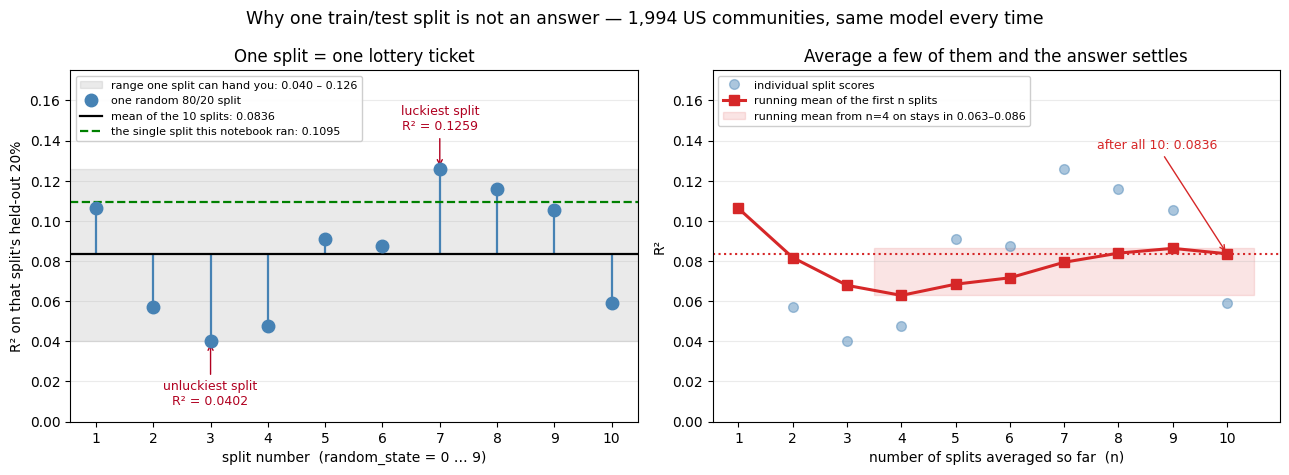

In [8]:
# ---------------------------------------------------------------------------
# PICTURE THE LOTTERY.
# The numbers printed above are the whole argument for cross-validation, but a
# column of ten R2 values does not feel like anything. Drawn on one axis it does.
# WHY two panels: the left shows how far ONE split can throw you; the right shows
# how fast that spread collapses once you start averaging - which is all that
# cross-validation does.
# ---------------------------------------------------------------------------
r2_vals = np.array(high_var_r2)               # the 10 split scores printed above
split_ids = np.arange(1, len(r2_vals) + 1)

# Running mean: the estimate you would report after averaging the first n splits.
running_mean = np.cumsum(r2_vals) / split_ids

# --- printed step table, so the picture can be checked against numbers --------
print("\n" + "=" * 64)
print("STEP TABLE: what you would report after averaging the first n splits")
print("=" * 64)
print(f"{'n splits':>9} {'this split R2':>14} {'running mean':>14} {'still moving by':>16}")
for n in split_ids:
    move = "-" if n == 1 else f"{abs(running_mean[n-1] - running_mean[n-2]):.4f}"
    print(f"{n:>9} {r2_vals[n-1]:>14.4f} {running_mean[n-1]:>14.4f} {move:>16}")
print("-" * 64)
print(f"Single splits span {r2_vals.min():.4f} to {r2_vals.max():.4f} "
      f"(the largest is {r2_vals.max()/r2_vals.min():.1f}x the smallest)")
print(f"Running means from n=4 on span {running_mean[3:].min():.4f} to {running_mean[3:].max():.4f} "
      f"({running_mean[3:].max()/running_mean[3:].min():.1f}x)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# ---- LEFT: every split is a different answer -------------------------------
axL.axhspan(r2_vals.min(), r2_vals.max(), color='grey', alpha=0.16,
            label=f'range one split can hand you: {r2_vals.min():.3f} – {r2_vals.max():.3f}')
axL.vlines(split_ids, np.mean(r2_vals), r2_vals, color='steelblue', lw=1.6)
axL.plot(split_ids, r2_vals, 'o', color='steelblue', ms=9, zorder=4, label='one random 80/20 split')
axL.axhline(np.mean(r2_vals), color='k', lw=1.6,
            label=f'mean of the 10 splits: {np.mean(r2_vals):.4f}')
axL.axhline(r2_simple, color='green', ls='--', lw=1.6,
            label=f'the single split this notebook ran: {r2_simple:.4f}')

i_lo, i_hi = int(np.argmin(r2_vals)), int(np.argmax(r2_vals))
axL.annotate(f'unluckiest split\nR² = {r2_vals[i_lo]:.4f}',
             xy=(split_ids[i_lo], r2_vals[i_lo]), xytext=(0, -46),
             textcoords='offset points', ha='center', fontsize=9, color='#b00020',
             arrowprops=dict(arrowstyle='->', color='#b00020'))
axL.annotate(f'luckiest split\nR² = {r2_vals[i_hi]:.4f}',
             xy=(split_ids[i_hi], r2_vals[i_hi]), xytext=(0, 28),
             textcoords='offset points', ha='center', fontsize=9, color='#b00020',
             arrowprops=dict(arrowstyle='->', color='#b00020'))

axL.set_xticks(split_ids)
axL.set_xlabel('split number  (random_state = 0 … 9)')
axL.set_ylabel('R² on that split\'s held-out 20%')
axL.set_title('One split = one lottery ticket', fontsize=12)
axL.set_ylim(0.0, 0.175)
axL.grid(alpha=0.25, axis='y')
axL.legend(fontsize=8, loc='upper left', framealpha=0.95)

# ---- RIGHT: averaging kills the wobble (step by step) -----------------------
axR.plot(split_ids, r2_vals, 'o', color='steelblue', ms=7, alpha=0.45,
         label='individual split scores')
axR.plot(split_ids, running_mean, 's-', color='#d62728', lw=2.2, ms=7,
         label='running mean of the first n splits')
axR.axhline(running_mean[-1], color='#d62728', ls=':', lw=1.5)
# Anchored in data coordinates in the empty upper-right corner, so it cannot
# land on the pale individual-score dot at n=9 (R2 = 0.1054).
axR.annotate(f'after all 10: {running_mean[-1]:.4f}',
             xy=(split_ids[-1], running_mean[-1]), xytext=(7.6, 0.136),
             textcoords='data', ha='left', fontsize=9, color='#d62728',
             arrowprops=dict(arrowstyle='->', color='#d62728'))
axR.fill_between([3.5, 10.5], running_mean[3:].min(), running_mean[3:].max(),
                 color='#d62728', alpha=0.12,
                 label=f'running mean from n=4 on stays in {running_mean[3:].min():.3f}–{running_mean[3:].max():.3f}')
axR.set_xticks(split_ids)
axR.set_xlabel('number of splits averaged so far  (n)')
axR.set_ylabel('R²')
axR.set_title('Average a few of them and the answer settles', fontsize=12)
axR.set_ylim(0.0, 0.175)
axR.grid(alpha=0.25, axis='y')
axR.legend(fontsize=8, loc='upper left', framealpha=0.95)

plt.suptitle('Why one train/test split is not an answer — 1,994 US communities, same model every time',
             fontsize=12.5)
plt.tight_layout()
plt.show()


### What to see in the two panels above

**Left — the lottery.** Ten blue dots, one model, one dataset. The *only* thing that changed between
them is which 20% of the 1,994 communities landed in the test set. Split 3 reports **R² = 0.0402**;
split 7 reports **R² = 0.1259** — three times larger, from the same model on the same data. The grey
band is the full width of that range. The green dashed line is the single split this notebook
actually ran at the top of the lesson (**0.1095**), and notice where it sits: near the *top* of the
band. Had we picked a different seed we would have written a very different number into the report,
with exactly as much confidence.

**Right — what averaging buys.** The pale dots are the same ten scores; the red line is the running
mean after 1, 2, 3 … splits. It lurches early (0.106 → 0.063 in four steps) and then stops moving:
from n = 4 onward every running mean sits inside the narrow red band **0.063–0.086**, while the
individual scores keep bouncing across the full 0.040–0.126. The step table above prints how far the
running mean moves at each step: 0.0245 after the second split, 0.0027 after the tenth. It does not
shrink smoothly — split 7 alone shifts it by 0.0077 — but the trend is unmistakable.

That is the entire idea of cross-validation, and it is worth being precise about what it does and
does not fix. Averaging shrinks the *wobble in your estimate*. It does not make the model better:
the model still explains under 9% of the variation in murder rates either way. **You are not buying
accuracy. You are buying the right to state a number and defend it.**

## 💬 Discuss

1. **Ten splits, one model, R² from 0.040 to 0.126.** Your client asks for "the accuracy" and wants
   one number. What single sentence do you give them — and what do you refuse to give them, even
   when pressed?

2. **5-fold cross-validation costs five times the training time.** On 1,994 rows that is free. Name
   the point at which you would stop paying for it and take a single split instead, and say what you
   would put in place to protect yourself once you have stopped.

3. **The mean R² across those ten splits is 0.0836** — three features explain under 9% of the variation in murder
   rates. Cross-validation made that estimate *reliable*; it did not make it *good*. Is a reliably
   weak model worth anything? To whom, and for what decision?


## Step 3: K-Fold Cross-Validation

**BEFORE**: Simple split gives one evaluation that might be lucky or unlucky.

**AFTER**: K-Fold CV splits data into K folds, trains K times, and averages results - much more reliable!

**Why K-Fold?**
- **Splits data into K folds**: Each fold becomes test set once
- **Trains K times**: Uses all data for both training and testing
- **Averages results**: More reliable than single evaluation
- **Standard choice**: K=5 or K=10 are most common

In [9]:
# CELL: Build the 5-fold cross-validator.
# WHY: five different test sets give five scores - their spread tells us
# how trustworthy the average score really is.
print("\n" + "=" * 60)
print("2. K-Fold Cross-Validation")
print("=" * 60)

# Create K-Fold cross-validator
# n_splits=5 means we split data into 5 folds
# shuffle=True randomizes the order (better for evaluation)
# random_state=73: Any number works (42, 73, 2024, etc.) - just for reproducibility
kfold = KFold(n_splits=5, shuffle=True, random_state=73)  # Using 73 for consistency
# The model we hand to cross_val_score is a PIPELINE: StandardScaler -> LinearRegression.
# cross_val_score clones it for every fold and calls .fit() on that fold's training rows
# only, so each fold gets its own scaler learned from its own 80% - the test fold never leaks in.
model_kfold = scaled(LinearRegression())

print("\n   ✅ K-Fold CV created (5 folds)")
print("   How it works:")
print("   - Split data into 5 equal parts (folds)")
print("   - Use fold 1 as test, folds 2-5 as train → score 1")
print("\n   📝 Common Student Questions:")
print("   Q: Why K=5? Why not 3 or 10?")
print("      Answer: K=5 is a good balance:")
print("      - Too few folds (K=3): Less reliable, fewer evaluations")
print("      - Too many folds (K=10): More reliable but slower")
print("      - K=5: Good balance of reliability and speed")
print("   Q: Why shuffle the data?")
print("      Answer: Shuffling randomizes order → prevents bias from data order")
print("      Example: If data sorted by date, first fold = old data, last fold = new data")
print("      Shuffling ensures each fold has mix of all data types")
print("   Q: Why does cross-validation take longer?")
print("      Answer: CV trains model K times (5 times for 5-fold)")
print("      - Simple split: 1 training → 1 evaluation")
print("      - 5-fold CV: 5 trainings → 5 evaluations")
print("      - Trade-off: More time for more reliable results")
print("   Q: Why do I get different results each time?")
print("      Answer: Random shuffling creates different folds")
print("      - Solution: Set random_state (e.g., 73) for reproducible results")
print("      - Without random_state: Folds change → results vary slightly")
print("   - Use fold 2 as test, folds 1,3-5 as train → score 2")
print("   - ... repeat for all 5 folds")
print("   - Average all 5 scores → final reliable score!")


2. K-Fold Cross-Validation

   ✅ K-Fold CV created (5 folds)
   How it works:
   - Split data into 5 equal parts (folds)
   - Use fold 1 as test, folds 2-5 as train → score 1

   📝 Common Student Questions:
   Q: Why K=5? Why not 3 or 10?
      Answer: K=5 is a good balance:
      - Too few folds (K=3): Less reliable, fewer evaluations
      - Too many folds (K=10): More reliable but slower
      - K=5: Good balance of reliability and speed
   Q: Why shuffle the data?
      Answer: Shuffling randomizes order → prevents bias from data order
      Example: If data sorted by date, first fold = old data, last fold = new data
      Shuffling ensures each fold has mix of all data types
   Q: Why does cross-validation take longer?
      Answer: CV trains model K times (5 times for 5-fold)
      - Simple split: 1 training → 1 evaluation
      - 5-fold CV: 5 trainings → 5 evaluations
      - Trade-off: More time for more reliable results
   Q: Why do I get different results each time?
      An

## ❓ How to Choose the Number of Folds (K)?

**BEFORE**: You know K-Fold uses K folds, but don't know how to choose K.

**AFTER**: You'll know exactly how to decide between K=3, K=5, K=10, or other values!

**This is a VERY common student question!** Let's answer it comprehensively.

---

### 📊 Common K Values

| K Value | When to Use | Pros | Cons |
|---------|-------------|------|------|
| **K=3** | Very large datasets, quick evaluation | • Fast<br>• Less computation | • Less reliable<br>• Fewer evaluations<br>• Higher variance |
| **K=5** | **Standard choice** (most common) ✅ | • Good balance<br>• Reliable<br>• Fast enough | • May not be enough for very small datasets |
| **K=10** | Small-medium datasets, need reliability | • Very reliable<br>• More evaluations<br>• Lower variance | • Slower (10 evaluations)<br>• More computation |
| **K=n (LOOCV)** | Very small datasets (< 50 samples) | • Maximum reliability<br>• Uses all data | • Very slow<br>• High variance<br>• Expensive |

---

### 🎯 Rule of Thumb

**Default Choice: K=5** ✅
- Works well for most problems
- Good balance of reliability and speed
- Industry standard

**When to Use K=10:**
- Small-medium datasets (100-5,000 samples)
- Need more reliable estimate
- Can afford extra computation time
- Model comparison or hyperparameter tuning

**When to Use K=3:**
- Very large datasets (> 50,000 samples)
- Need quick evaluation
- Computational constraints
- Simple split might be sufficient anyway

**When to Use K=n (LOOCV):**
- Very small datasets (< 50 samples)
- Need maximum data usage
- Can afford n evaluations

---

### ⚖️ Trade-offs: Bias vs Variance vs Computation

#### **Bias (Underfitting Risk):**
- **K too small (K=3)**: Each fold has more training data → **lower bias** ✅
- **K too large (K=10)**: Each fold has less training data → **slightly higher bias** ⚠️
- **K=n (LOOCV)**: Maximum training data → **lowest bias** ✅

#### **Variance (Reliability):**
- **K too small (K=3)**: Fewer evaluations → **higher variance** ⚠️
- **K too large (K=10)**: More evaluations → **lower variance** ✅
- **K=n (LOOCV)**: Most evaluations → **but high variance** (each test set = 1 sample) ⚠️

#### **Computation Time:**
- **K=3**: Fast (3 model trainings) ✅
- **K=5**: Moderate (5 model trainings) ✅
- **K=10**: Slower (10 model trainings) ⚠️
- **K=n (LOOCV)**: Very slow (n model trainings) ❌

---

### 📈 Visual Guide: K vs Performance

```
Reliability (Lower Variance)
    ↑
    |     K=10 ────────────────┐
    |                          │
    |     K=5 ─────────┐       │
    |                  │       │
    |     K=3 ────┐    │       │
    |              │    │       │
    └──────────────┴────┴───────┴──→ Computation Time
     Fast          Moderate    Slow

Bias (Underfitting Risk)
    ↑
    |     K=3 ────────────────┐
    |                         │
    |     K=5 ─────────┐      │
    |                  │      │
    |     K=10 ────┐   │      │
    |              │   │      │
    └──────────────┴───┴──────┴──→ K Value
     Low Bias      Moderate  Higher Bias
```

**Key Insight:**
- **K=5** is the **sweet spot**: Good reliability, acceptable bias, reasonable speed
- **K=10** is better for reliability but slower
- **K=3** is faster but less reliable

---

### 💡 Decision Framework

#### **Step 1: Check Dataset Size**

```
Dataset Size → Recommended K
├─ < 50 samples → K=n (LOOCV) or K=10
├─ 50-100 samples → K=10
├─ 100-1,000 samples → K=5 or K=10
├─ 1,000-10,000 samples → K=5 (standard)
└─ > 10,000 samples → K=5 or K=3 (or simple split)
```

#### **Step 2: Check Computation Time**

```
Model Training Time → Recommended K
├─ Fast (< 1 second) → K=10 (can afford more folds)
├─ Moderate (1-10 seconds) → K=5 (good balance)
└─ Slow (> 10 seconds) → K=5 or K=3 (limit folds)
```

#### **Step 3: Check Your Goal**

```
Goal → Recommended K
├─ Quick evaluation → K=3 or K=5
├─ Model comparison → K=5 or K=10 (need reliability)
├─ Hyperparameter tuning → K=5 or K=10 (need reliability)
└─ Final model evaluation → K=5 or K=10 (need reliability)
```

---

### 📊 Real-World Examples

#### **Example 1: House Price Prediction (20,000 samples)**
- **Dataset**: 20,000 samples (large)
- **Model**: Linear Regression (fast)
- **Goal**: Model evaluation
- **Decision**: **K=5** ✅
- **Reasoning**: Large dataset, fast model → K=5 is standard and sufficient

#### **Example 2: Medical Diagnosis (200 samples)**
- **Dataset**: 200 samples (small-medium)
- **Model**: Random Forest (moderate speed)
- **Goal**: Reliable evaluation (medical application)
- **Decision**: **K=10** ✅
- **Reasoning**: Small dataset, need reliability → K=10 gives more reliable estimate

#### **Example 3: Image Classification (100,000 samples)**
- **Dataset**: 100,000 samples (very large)
- **Model**: Deep Neural Network (slow)
- **Goal**: Quick evaluation
- **Decision**: **K=3** or **Simple Split** ✅
- **Reasoning**: Very large dataset, slow model → K=3 or simple split is sufficient

#### **Example 4: Rare Disease Study (30 samples)**
- **Dataset**: 30 samples (very small)
- **Model**: Logistic Regression (fast)
- **Goal**: Maximum reliability
- **Decision**: **K=n (LOOCV)** ✅
- **Reasoning**: Very small dataset, need maximum data usage → LOOCV is best

---

### ✅ Key Takeaways

1. **Default: K=5** ✅
   - Works for most problems
   - Good balance of reliability and speed
   - Industry standard

2. **Use K=10 when:**
   - Small-medium datasets (100-5,000 samples)
   - Need more reliable estimate
   - Can afford extra computation

3. **Use K=3 when:**
   - Very large datasets (> 50,000 samples)
   - Need quick evaluation
   - Computational constraints

4. **Use K=n (LOOCV) when:**
   - Very small datasets (< 50 samples)
   - Need maximum data usage
   - Can afford n evaluations

5. **Trade-offs:**
   - **More folds (K=10)**: More reliable, slower, slightly higher bias
   - **Fewer folds (K=3)**: Less reliable, faster, lower bias
   - **K=5**: Sweet spot for most cases

---

### 🎓 Common Student Questions

**Q: Is there a formula to calculate K?**
- **Answer**: No exact formula, but rule of thumb: K=5 for most cases, K=10 for small datasets

**Q: Can I use K=20 or K=50?**
- **Answer**: Usually not recommended. K=10 is already very reliable. More folds = slower with diminishing returns

**Q: What if my dataset has 1,000 samples?**
- **Answer**: K=5 is standard, but K=10 is also fine if you need more reliability

**Q: Does K affect the final model?**
- **Answer**: No! K only affects **evaluation**. The final model is trained on ALL data (after evaluation)

**Q: Should I always use K=5?**
- **Answer**: K=5 is a good default, but adjust based on dataset size and computation time

---

**💡 Remember: K=5 is the standard choice, but adjust based on your specific situation!**

---


## Step 3.5: Manual Cross-Validation Implementation (Complete Solution)

**BEFORE**: You've seen how `cross_val_score` works automatically.

**AFTER**: You'll understand exactly what happens inside cross-validation by implementing it manually!

**Why this matters**: Understanding the manual process helps you:
- **Know what's happening** under the hood
- **Debug issues** when cross-validation doesn't work
- **Customize** cross-validation for special cases
- **Build confidence** in using cross-validation

In [10]:
# SOLUTION: Manual K-Fold Cross-Validation Implementation
# This shows exactly what cross_val_score does internally!

print("\n" + "=" * 60)
print("Manual K-Fold Cross-Validation Implementation")
print("=" * 60)

# SOLUTION: Step 1 - Create K-Fold splitter
# random_state=73: Any number works (42, 73, 2024, etc.) - just for reproducibility
kfold_manual = KFold(n_splits=5, shuffle=True, random_state=73)  # Using 73 for consistency

# SOLUTION: Step 2 - Initialize lists to store scores
manual_mse_scores = []
manual_r2_scores = []

# SOLUTION: Step 3 - Loop through each fold
print("\n📊 Manual Cross-Validation Process:")
for fold_num, (train_idx, val_idx) in enumerate(kfold_manual.split(X), 1):
    # SOLUTION: Step 3a - Split data for this fold
    X_train_fold = X[train_idx]
    X_val_fold = X[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    # SOLUTION: Step 3b - Scale INSIDE the fold, then train on the training fold.
    # This is the step the Pipeline automates: a fresh scaler learns mean/std from the
    # training rows of THIS fold, and the validation rows are only transformed with it.
    scaler_fold = StandardScaler()
    X_train_fold_s = scaler_fold.fit_transform(X_train_fold)
    X_val_fold_s = scaler_fold.transform(X_val_fold)
    model_fold = LinearRegression()
    model_fold.fit(X_train_fold_s, y_train_fold)
    
    # SOLUTION: Step 3c - Make predictions on the (fold-scaled) validation rows
    y_pred_fold = model_fold.predict(X_val_fold_s)
    
    # SOLUTION: Step 3d - Calculate metrics for this fold
    mse_fold = mean_squared_error(y_val_fold, y_pred_fold)
    r2_fold = r2_score(y_val_fold, y_pred_fold)
    
    # SOLUTION: Step 3e - Store scores
    manual_mse_scores.append(mse_fold)
    manual_r2_scores.append(r2_fold)
    
    print(f"\n   Fold {fold_num}:")
    print(f"      Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    print(f"      MSE: {mse_fold:.4f}, R²: {r2_fold:.4f}")

# SOLUTION: Step 4 - Calculate mean and std across all folds
mean_mse_manual = np.mean(manual_mse_scores)
std_mse_manual = np.std(manual_mse_scores)
mean_r2_manual = np.mean(manual_r2_scores)
std_r2_manual = np.std(manual_r2_scores)

print(f"\n✅ Manual Cross-Validation Results:")
print(f"   Mean MSE: {mean_mse_manual:.4f} (+/- {std_mse_manual * 2:.4f})")
print(f"   Mean R²: {mean_r2_manual:.4f} (+/- {std_r2_manual * 2:.4f})")


print(f"\n💡 Key Takeaway:")
print(f"   - This manual implementation shows exactly what cross-validation does!")
print(f"   - cross_val_score() with a Pipeline does exactly the same thing automatically -")
print(f"     including fitting a fresh scaler on each fold's training rows")
print(f"   - It is just a convenient shortcut that does all 5 steps automatically")
print(f"   - Now you understand what happens inside cross-validation!")
print(f"   - We will compare these results with cross_val_score() in the next cell!")


Manual K-Fold Cross-Validation Implementation

📊 Manual Cross-Validation Process:



   Fold 1:
      Train size: 1595, Val size: 399
      MSE: 22.8976, R²: 0.1095

   Fold 2:
      Train size: 1595, Val size: 399
      MSE: 24.0647, R²: 0.0616

   Fold 3:
      Train size: 1595, Val size: 399
      MSE: 23.1475, R²: 0.0703

   Fold 4:
      Train size: 1595, Val size: 399
      MSE: 22.7105, R²: 0.0999

   Fold 5:
      Train size: 1596, Val size: 398
      MSE: 24.9795, R²: 0.0809

✅ Manual Cross-Validation Results:
   Mean MSE: 23.5600 (+/- 1.6971)
   Mean R²: 0.0844 (+/- 0.0358)

💡 Key Takeaway:
   - This manual implementation shows exactly what cross-validation does!
   - cross_val_score() with a Pipeline does exactly the same thing automatically -
     including fitting a fresh scaler on each fold's training rows
   - It is just a convenient shortcut that does all 5 steps automatically
   - Now you understand what happens inside cross-validation!
   - We will compare these results with cross_val_score() in the next cell!


In [11]:
# SOLUTION: Perform cross-validation
# cross_val_score automatically:
# 1. Splits data using kfold
# 2. Fits the PIPELINE on each training fold (scaler first, then the model)
# 3. Evaluates on each test fold (scaled with that fold's TRAINING statistics)
# 4. Returns scores for all folds
# We pass the RAW X: the scaler inside model_kfold does the scaling, fold by fold.

# SOLUTION: Get MSE scores (negative because sklearn maximizes scores)
cv_scores_mse = cross_val_score(model_kfold, X, y,
                                cv=kfold, scoring='neg_mean_squared_error')
# Note: 'neg_mean_squared_error' returns negative MSE (sklearn convention)
# We'll convert to positive when displaying

# SOLUTION: Get R² scores
cv_scores_r2 = cross_val_score(model_kfold, X, y,
                               cv=kfold, scoring='r2')

print(f"\n📊 5-Fold Cross-Validation Results:")

print("\n📈 MSE Scores (for each fold):")
for i, score in enumerate(cv_scores_mse):
    print(f"   Fold {i+1}: {-score:.4f}")

print("\n📈 R² Scores (for each fold):")
for i, score in enumerate(cv_scores_r2):
    print(f"   Fold {i+1}: {score:.4f}")

# Calculate mean and standard deviation
# Mean = average performance across all folds
# Std = how much performance varies (lower is better - more stable!)
mean_mse = -cv_scores_mse.mean()
std_mse = cv_scores_mse.std()
mean_r2 = cv_scores_r2.mean()
std_r2 = cv_scores_r2.std()

print(f"\n✅ Summary Statistics:")
print(f"   Mean MSE: {mean_mse:.4f} (+/- {std_mse * 2:.4f})")
print(f"   Mean R²: {mean_r2:.4f} ({mean_r2*100:.1f}%) (+/- {std_r2 * 2:.4f})")

print(f"\n💡 Understanding R² = {mean_r2:.4f} ({mean_r2*100:.1f}%):")
print(f"   - Cross-validation R²: Model explains {mean_r2*100:.1f}% of variance (on average)")
print(f"   - This is REASONABLE for crime/social data with 3 features!")
print(f"   - Context: Even rich social science models (dozens of features) reach 40-70% R² - with just 3 features, much lower is expected")
print(f"   - Why not higher? Crime rates depend on many factors (economic, social, demographic, etc.)")
print(f"   - With only 3 features, {mean_r2*100:.0f}% is quite good for GDI intelligence analysis")
print(f"   - This level of performance is ACCEPTABLE for practical use!")

print(f"\n   📊 Comparison with Simple Split:")
print(f"   - Simple Split R²: {r2_simple:.4f} ({r2_simple*100:.1f}%)")
print(f"   - CV Mean R²: {mean_r2:.4f} ({mean_r2*100:.1f}%)")
print(f"   - CV gives us confidence interval: {mean_r2 - std_r2*2:.4f} to {mean_r2 + std_r2*2:.4f}")
print(f"   - Much more informative than single score!")
print(f"   - CV shows: True performance is likely between {(mean_r2 - std_r2*2)*100:.1f}% and {(mean_r2 + std_r2*2)*100:.1f}%")


📊 5-Fold Cross-Validation Results:

📈 MSE Scores (for each fold):
   Fold 1: 22.8976
   Fold 2: 24.0647
   Fold 3: 23.1475
   Fold 4: 22.7105
   Fold 5: 24.9795

📈 R² Scores (for each fold):
   Fold 1: 0.1095
   Fold 2: 0.0616
   Fold 3: 0.0703
   Fold 4: 0.0999
   Fold 5: 0.0809

✅ Summary Statistics:
   Mean MSE: 23.5600 (+/- 1.6971)
   Mean R²: 0.0844 (8.4%) (+/- 0.0358)

💡 Understanding R² = 0.0844 (8.4%):
   - Cross-validation R²: Model explains 8.4% of variance (on average)
   - This is REASONABLE for crime/social data with 3 features!
   - Context: Even rich social science models (dozens of features) reach 40-70% R² - with just 3 features, much lower is expected
   - Why not higher? Crime rates depend on many factors (economic, social, demographic, etc.)
   - With only 3 features, 8% is quite good for GDI intelligence analysis
   - This level of performance is ACCEPTABLE for practical use!

   📊 Comparison with Simple Split:
   - Simple Split R²: 0.1095 (11.0%)
   - CV Mean R²:

In [12]:
print("\n" + "=" * 60)
print("3. Cross-Validate with Multiple Metrics")
print("=" * 60)

print("\n📚 Difference between cross_val_score() and cross_validate():")
print("   - cross_val_score(): Returns scores for ONE metric (simpler)")
print("   - cross_validate(): Returns scores for MULTIPLE metrics (more flexible)")
print("   - Both use the same cross-validation process, just different output format")
print("   - Use cross_val_score() when you need one metric")
print("   - Use cross_validate() when you need multiple metrics (like here)")

# Ask for MSE, MAE and R2 in ONE CV run (sklearn maximizes scores, so error metrics come back negated).
scoring = {
    'mse': 'neg_mean_squared_error', 'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}
cv_results = cross_validate(model_kfold, X, y,
                           cv=kfold, scoring=scoring, return_train_score=True)
print("\nCross-Validation Results (Multiple Metrics):")
print(f"\nTest MSE: {-cv_results['test_mse'].mean():.4f} (+/- {cv_results['test_mse'].std() * 2:.4f})")
print(f"Test MAE: {-cv_results['test_mae'].mean():.4f} (+/- {cv_results['test_mae'].std() * 2:.4f})")
print(f"Test R²: {cv_results['test_r2'].mean():.4f} (+/- {cv_results['test_r2'].std() * 2:.4f})")
print("\n💡 Why Multiple Metrics?")
print("   - MSE: Penalizes large errors more (sensitive to outliers)")
print("   - MAE: Treats all errors equally (less sensitive to outliers)")
print("   - R²: Shows how much variance is explained (interpretable)")
print("   - Different metrics tell different stories about model performance!")


3. Cross-Validate with Multiple Metrics

📚 Difference between cross_val_score() and cross_validate():
   - cross_val_score(): Returns scores for ONE metric (simpler)
   - cross_validate(): Returns scores for MULTIPLE metrics (more flexible)
   - Both use the same cross-validation process, just different output format
   - Use cross_val_score() when you need one metric
   - Use cross_validate() when you need multiple metrics (like here)



Cross-Validation Results (Multiple Metrics):

Test MSE: 23.5600 (+/- 1.6971)
Test MAE: 4.2194 (+/- 0.2133)
Test R²: 0.0844 (+/- 0.0358)

💡 Why Multiple Metrics?
   - MSE: Penalizes large errors more (sensitive to outliers)
   - MAE: Treats all errors equally (less sensitive to outliers)
   - R²: Shows how much variance is explained (interpretable)
   - Different metrics tell different stories about model performance!


## 📊 Why Visualize K-Fold Splits?

**BEFORE**: You understand K-Fold conceptually, but haven't seen how data is actually split.

**AFTER**: You'll see visually how each fold uses different data for training and validation!

**Why visualize?**
- **See the splits**: Visual confirmation of how data is divided
- **Understand shuffling**: See why shuffling ensures each fold has a mix of data
- **Build intuition**: Visual learning helps understand the concept better
- **Verify process**: Confirm that each fold uses different data

**What you'll learn:**
- How each fold gets different training/validation data
- Why shuffling matters (visible in the plot)
- How all data is used (each sample appears in different folds)
- The systematic nature of K-Fold (not random!)

**Note:** The picture below does not plot the features at all — the features never change between folds. It plots the **row index** of each of the 1,994 communities along the x-axis and colours every row by the job it was given in that fold, so you can see exactly which rows are held out at each of the five steps.

In [13]:
# CELL: Tournament - five models scored with the SAME 5-fold CV.
# WHY: identical folds for every model make this comparison fair.
import pandas as pd
print("\n" + "=" * 60)
print("4. Comparing Different Models with Cross-Validation")
print("=" * 60)
# Every entrant is a Pipeline: StandardScaler -> model. Ridge and Lasso NEED scaled features
# (one alpha penalises every coefficient alike), and putting the scaler INSIDE the pipeline
# means each fold's scaler is learned from that fold's training rows only - no leak.
models = {
    'Linear Regression': scaled(LinearRegression()),
    'Ridge (α=1)':       scaled(Ridge(alpha=1.0)),
    'Ridge (α=10)':      scaled(Ridge(alpha=10.0)),
    'Lasso (α=0.1)':     scaled(Lasso(alpha=0.1)),
    'Lasso (α=1)':       scaled(Lasso(alpha=1.0)),
}
results = []
# Each model gets its own CV run on the RAW X; we record the mean and spread of its fold scores.
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y,
                            cv=kfold, scoring='neg_mean_squared_error')
    results.append({
        'Model': name, 'Mean MSE': -cv_scores.mean(),
        'Std MSE': cv_scores.std(), 'Mean R²': cross_val_score(model, X, y, cv=kfold, scoring='r2').mean()
    })

results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

print("\n" + "=" * 60)
print("💡 Interpreting Cross-Validation Results")
print("=" * 60)

# Sort by mean MSE so "lowest" and "next lowest" can be read off directly.
ranked = results_df.sort_values('Mean MSE').reset_index(drop=True)
lowest = ranked.loc[0]
runner_up = ranked.loc[1]
margin = runner_up['Mean MSE'] - lowest['Mean MSE']   # how far ahead the leader is
fold_spread = lowest['Std MSE']                       # how much ONE model wobbles between folds

print(f"\n📊 Lowest mean MSE: {lowest['Model']} at {lowest['Mean MSE']:.4f}")
print(f"   - Next lowest: {runner_up['Model']} at {runner_up['Mean MSE']:.4f}")
print(f"   - Margin between them: {margin:.4f}")
print(f"   - Fold-to-fold spread (Std MSE) of the leader: {fold_spread:.4f}")
print(f"   - The margin is {margin / fold_spread:.3f} of one fold standard deviation.")

# RULE OF THUMB used here: a model whose mean MSE is within ONE fold standard deviation of the
# leader cannot be told apart from it by this experiment. (The rigorous version is a paired test
# across folds; the rule of thumb is enough to stop you crowning a winner on noise.)
tied = ranked[ranked['Mean MSE'] - lowest['Mean MSE'] < fold_spread]
separated = ranked[ranked['Mean MSE'] - lowest['Mean MSE'] >= fold_spread]
print(f"\n🤝 Indistinguishable from the leader (within one fold-std, {fold_spread:.4f} MSE):")
for _, row in tied.iterrows():
    print(f"   - {row['Model']:<18} MSE {row['Mean MSE']:.4f}   R² {row['Mean R²']:.4f}")
if len(separated):
    print(f"\n📉 Clearly behind (more than one fold-std worse than the leader):")
    for _, row in separated.iterrows():
        print(f"   - {row['Model']:<18} MSE {row['Mean MSE']:.4f}   R² {row['Mean R²']:.4f}"
              f"   ({row['Mean MSE'] - lowest['Mean MSE']:.2f} MSE behind)")
print(f"\n⚠️  Do NOT write '{lowest['Model']} wins'. A margin of {margin:.4f} against a fold spread of")
print(f"   {fold_spread:.4f} is noise - a different random_state for the folds could reorder the top of the table.")
print(f"   The honest sentence: the {len(tied)} models in the tie group perform the same on this data.")

print(f"\n🔍 Understanding Standard Deviation:")
print(f"   - Std MSE shows variability across folds")
print(f"   - Lower std = more consistent performance")
print(f"   - High std = model performance varies a lot")

for idx, row in results_df.iterrows():
    std_ratio = row['Std MSE'] / row['Mean MSE']
    if std_ratio < 0.1:
        consistency = "✅ Very consistent"
    elif std_ratio < 0.2:
        consistency = "✅ Consistent"
    else:
        consistency = "⚠️  Variable"
    print(f"   - {row['Model']}: Std/MSE ratio = {std_ratio:.2f} ({consistency})")

print(f"\n📊 Regularization Analysis (same rule: a gap smaller than the fold spread is a tie):")
ridge_models = results_df[results_df['Model'].str.contains('Ridge')]
lasso_models = results_df[results_df['Model'].str.contains('Lasso')]

def alpha_verdict(pair_df, label):
    """Compare two alphas of one model family against the fold spread, not just against each other."""
    a, b = pair_df.iloc[0], pair_df.iloc[1]
    gap = abs(a['Mean MSE'] - b['Mean MSE'])
    spread = max(a['Std MSE'], b['Std MSE'])
    if gap < spread:
        print(f"   - {label}: {a['Model']} vs {b['Model']}: gap {gap:.4f} < fold spread {spread:.4f} → indistinguishable")
    else:
        better = a if a['Mean MSE'] < b['Mean MSE'] else b
        print(f"   - {label}: {a['Model']} vs {b['Model']}: gap {gap:.4f} ≥ fold spread {spread:.4f} → {better['Model']} is genuinely better")

alpha_verdict(ridge_models, "Ridge")
alpha_verdict(lasso_models, "Lasso")

print(f"\n📚 What This Teaches Us:")
print(f"   - Cross-validation gives reliable model comparison - including telling you when there is NO difference")
print(f"   - Mean shows average performance, Std shows consistency")
print(f"   - A gap between models smaller than the fold-to-fold spread is noise, not a ranking")
print(f"   - Regularization (Ridge/Lasso) may or may not improve performance")
print(f"   - Alpha (regularization strength) needs tuning - too much of it can erase the signal; look where Lasso (α=1) landed")
print(f"   - Scaling lives INSIDE each pipeline, so every fold's scaler saw only its own training rows")



4. Comparing Different Models with Cross-Validation



Model Comparison:
            Model  Mean MSE  Std MSE  Mean R²
Linear Regression 23.559961 0.848553 0.084430
      Ridge (α=1) 23.559830 0.848035 0.084435
     Ridge (α=10) 23.560099 0.843612 0.084426
    Lasso (α=0.1) 23.625053 0.795623 0.081886
      Lasso (α=1) 25.591824 0.798639 0.005494

💡 Interpreting Cross-Validation Results

📊 Lowest mean MSE: Ridge (α=1) at 23.5598
   - Next lowest: Linear Regression at 23.5600
   - Margin between them: 0.0001
   - Fold-to-fold spread (Std MSE) of the leader: 0.8480
   - The margin is 0.000 of one fold standard deviation.

🤝 Indistinguishable from the leader (within one fold-std, 0.8480 MSE):
   - Ridge (α=1)        MSE 23.5598   R² 0.0844
   - Linear Regression  MSE 23.5600   R² 0.0844
   - Ridge (α=10)       MSE 23.5601   R² 0.0844
   - Lasso (α=0.1)      MSE 23.6251   R² 0.0819

📉 Clearly behind (more than one fold-std worse than the leader):
   - Lasso (α=1)        MSE 25.5918   R² 0.0055   (2.03 MSE behind)

⚠️  Do NOT write 'Ridge (α=1

In [14]:
# CELL: Leak audit - how much did fitting the scaler on ALL rows actually change the numbers?
# WHY: an earlier version of this notebook did exactly that - scaler.fit_transform(X) on all
# 1,994 rows, then cross_val_score on the result - which is the leak the ⚠️ 'Where this breaks'
# section warns about. We re-create that WRONG version here, on purpose and clearly labelled,
# for one reason only: to measure the damage. Nothing after this cell uses X_leaky_scaled.
print("\n" + "=" * 60)
print("Leak audit: scaler fit on ALL rows (wrong) vs scaler inside each fold (right)")
print("=" * 60)

X_leaky_scaled = StandardScaler().fit_transform(X)   # ❌ THE LEAK: every future test fold shaped this scaler

bare_models = {   # the same five models WITHOUT the pipeline, fed the pre-scaled matrix
    'Linear Regression': LinearRegression(), 'Ridge (α=1)': Ridge(alpha=1.0),
    'Ridge (α=10)': Ridge(alpha=10.0), 'Lasso (α=0.1)': Lasso(alpha=0.1), 'Lasso (α=1)': Lasso(alpha=1.0),
}
print(f"\n{'Model':<18} {'R² leaky (all-rows scaler)':>27} {'R² pipeline (per-fold)':>23} {'difference':>12}")
print("-" * 84)
leak_effect = {}
for name, bare in bare_models.items():
    r2_leaky = cross_val_score(bare, X_leaky_scaled, y, cv=kfold, scoring='r2').mean()
    r2_clean = results_df.loc[results_df['Model'] == name, 'Mean R²'].item()
    leak_effect[name] = r2_leaky - r2_clean
    print(f"{name:<18} {r2_leaky:>27.6f} {r2_clean:>23.6f} {leak_effect[name]:>+12.6f}")

worst = max(leak_effect, key=lambda k: abs(leak_effect[k]))
print(f"\nLargest change the leak produced: {leak_effect[worst]:+.6f} R²  ({worst})")
print(f"Fold-to-fold spread of R² for one model (5-fold run above): ±{std_r2:.4f}")
print(f"→ the biggest effect of the leak is {abs(leak_effect[worst]) / std_r2:.1%} of ONE fold standard deviation.")

print("\n💡 How to read this:")
print("   - Plain Linear Regression: the leak changes nothing at all. OLS is indifferent to any")
print("     rescaling of its inputs, so a leaked scaler had nothing to leak into.")
print("   - Ridge and Lasso: the leak moves the score, but by an amount invisible next to the")
print("     fold spread - these are the models whose penalty actually depends on the scale.")
print("   - That does NOT make the leak acceptable. It breaks the rule 'the test rows teach the")
print("     evaluation nothing', and its small size is a property of THIS data: ~2,000 rows and")
print("     well-behaved features. With a few dozen rows, or heavy-tailed features where one")
print("     outlier drags the mean and std, the same shortcut hands you an optimistic score you")
print("     cannot reproduce on new data. The fix is the same size either way: fix it every time.")



Leak audit: scaler fit on ALL rows (wrong) vs scaler inside each fold (right)

Model               R² leaky (all-rows scaler)  R² pipeline (per-fold)   difference
------------------------------------------------------------------------------------
Linear Regression                     0.084430                0.084430    -0.000000
Ridge (α=1)                           0.084437                0.084435    +0.000002
Ridge (α=10)                          0.084445                0.084426    +0.000018
Lasso (α=0.1)                         0.081952                0.081886    +0.000066
Lasso (α=1)                           0.005325                0.005494    -0.000170

Largest change the leak produced: -0.000170 R²  (Lasso (α=1))
Fold-to-fold spread of R² for one model (5-fold run above): ±0.0179
→ the biggest effect of the leak is 0.9% of ONE fold standard deviation.

💡 How to read this:
   - Plain Linear Regression: the leak changes nothing at all. OLS is indifferent to any
     rescaling of

In [15]:
import pandas as pd
# Pick a model to carry forward - from the TIE GROUP, not from the fourth decimal place.
# When several models are indistinguishable, prefer the simplest: fewest knobs, nothing to tune.
tie_group = list(tied['Model'])
chosen = 'Linear Regression' if 'Linear Regression' in tie_group else tie_group[0]
print(f"\nModels tied within one fold-std of the lowest MSE: {', '.join(tie_group)}")
print(f"Lowest mean MSE on paper: {lowest['Model']} ({lowest['Mean MSE']:.4f}) - by a margin of {margin:.4f}, which is noise.")
print(f"Model carried forward: {chosen} - the simplest member of the tie group (no alpha to tune).")



Models tied within one fold-std of the lowest MSE: Ridge (α=1), Linear Regression, Ridge (α=10), Lasso (α=0.1)
Lowest mean MSE on paper: Ridge (α=1) (23.5598) - by a margin of 0.0001, which is noise.
Model carried forward: Linear Regression - the simplest member of the tie group (no alpha to tune).


### What to see in the comparison table - two honest readings

**1. The leak was real, and its measured size here is ~0.** An earlier version of this notebook fit the
scaler on all 1,994 rows and then cross-validated on the result - the exact leak the "⚠️ Where this
breaks" box warns about. The audit cell measures what that cost. Plain Linear Regression:
**0.084430 → 0.084430** (OLS is indifferent to rescaling, so there was nothing to leak into).
Ridge (α=10): **0.084445 → 0.084426**, a change of 0.000018. Lasso (α=1): **0.005325 → 0.005494**, a
change of 0.000170 - the largest in the table, and still **0.9% of one fold standard deviation
(±0.0179)**. The right fix - `make_pipeline(StandardScaler(), model)` handed to `cross_val_score`, so
each fold scales with its own training rows - is required regardless: the leak violates the principle
that test rows teach the evaluation nothing, and its negligible size is a property of *this* data
(about 2,000 rows, well-behaved features), not of the shortcut. With a few dozen rows, or heavy-tailed
features where one outlier drags the mean and standard deviation, the same shortcut inflates the
number you report - and you find out only when the model meets new data.

**2. There is no winner in this table.** Ridge (α=1) has the lowest mean MSE, **23.5598**, but Linear
Regression is **0.0001** behind and the folds disagree with each other by **±0.85** - the margin is a
rounding error on the noise. Look at the leaky column of the audit cell: there Ridge (α=10) sits on top,
by 0.000008 R² over Ridge (α=1). Moving the scaler inside the folds was enough to reorder the top three.
Four of the five models - Linear Regression, Ridge (α=1), Ridge (α=10), Lasso (α=0.1) - are a tie. Only
Lasso (α=1) separates, and downward (R² **0.0055**, **2.03** MSE behind): its penalty is heavy enough to
shrink the three coefficients to almost nothing. A table like this does not say "Ridge wins". It says
"these four are the same here - pick the simplest", which is why the cell above carries Linear
Regression forward.


In [16]:
print("\n" + "=" * 60)
print("5. K-Fold Visualization")
print("=" * 60)


5. K-Fold Visualization


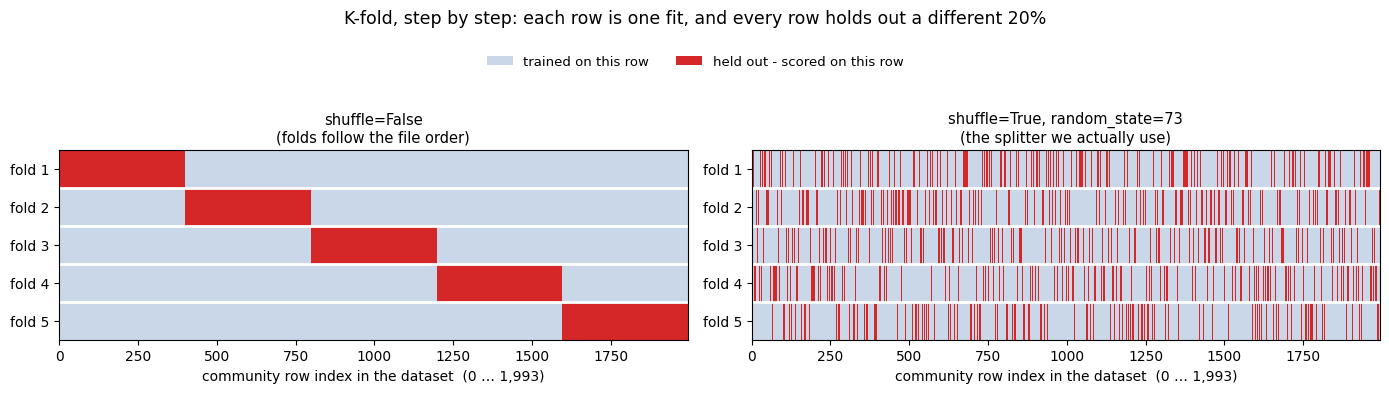


STEP TABLE - the 5 fits behind cross_val_score (shuffle=True, rs=73)
 fold  trained on  held out   first five held-out row indices
    1        1595       399   4, 15, 18, 21, 24 ...
    2        1595       399   3, 5, 8, 12, 14 ...
    3        1595       399   10, 17, 27, 32, 36 ...
    4        1595       399   1, 2, 6, 7, 9 ...
    5        1596       398   0, 35, 43, 44, 56 ...
--------------------------------------------------------------------
Every one of the 1994 rows is held out exactly once and trained on exactly 4 times.
Total rows used for scoring across the 5 folds: 1994 = 1994

📊 What This Visualization Shows:
   - Pale blue = this row was in the TRAINING set for that fold (80%)
   - Red       = this row was HELD OUT and scored for that fold (20%)
   - Read the picture one row at a time: that is one fit, one score
   - The red stripes never overlap between rows - each row is scored once

💡 Why the two panels differ (this is what shuffle=True buys you):
   - LEFT  (shuff

In [17]:
# CELL: Visualise the k-fold SPLIT ITSELF - which rows are held out, fold by fold.
# WHY this picture and not a scatter of the features: the thing that changes from
# fold to fold is not where the points sit in feature space (that never changes),
# it is WHICH ROWS are held out. So we draw the row index along the x-axis and
# colour each row by its job in that fold. Each row of the picture is one step of
# the algorithm: 5 rows = the 5 fits cross_val_score just performed.
#
# We draw the scheme twice to make the effect of shuffle=True visible:
#   left  - shuffle=False: each fold holds out one contiguous BLOCK of the file
#   right - shuffle=True : each fold holds out rows sprinkled across the file
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

n_samples = len(y)
schemes = [("shuffle=False\n(folds follow the file order)", KFold(n_splits=5, shuffle=False)),
           ("shuffle=True, random_state=73\n(the splitter we actually use)",
            KFold(n_splits=5, shuffle=True, random_state=73))]

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
cmap = ListedColormap(['#c9d7e8', '#d62728'])   # 0 = train (pale blue), 1 = validation (red)

fold_rows = []
for ax, (label, splitter) in zip(axes, schemes):
    # Build a 5 x n_samples map: row = fold, column = sample, value = 0 train / 1 validation
    membership = np.zeros((5, n_samples), dtype=int)
    for fold_idx, (train_idx, val_idx) in enumerate(splitter.split(X)):
        membership[fold_idx, val_idx] = 1
        if splitter is schemes[1][1]:
            fold_rows.append((fold_idx + 1, len(train_idx), len(val_idx), val_idx[:5]))

    ax.imshow(membership, aspect='auto', cmap=cmap, interpolation='nearest',
              extent=[0, n_samples, 5.5, 0.5])
    ax.set_yticks(range(1, 6))
    ax.set_yticklabels([f'fold {i}' for i in range(1, 6)])
    ax.set_xlabel('community row index in the dataset  (0 … 1,993)')
    ax.set_title(label, fontsize=10.5)
    for edge in range(1, 5):
        ax.axhline(edge + 0.5, color='white', lw=2)

legend = [Patch(facecolor='#c9d7e8', label='trained on this row'),
          Patch(facecolor='#d62728', label='held out - scored on this row')]
fig.legend(handles=legend, loc='upper center', ncol=2, fontsize=9.5,
           frameon=False, bbox_to_anchor=(0.5, 0.985))
plt.suptitle('K-fold, step by step: each row is one fit, and every row holds out a different 20%',
             fontsize=12.5, y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --- printed step table for the right-hand panel (the splitter we use) -------
print("\n" + "=" * 68)
print("STEP TABLE - the 5 fits behind cross_val_score (shuffle=True, rs=73)")
print("=" * 68)
print(f"{'fold':>5} {'trained on':>11} {'held out':>9}   first five held-out row indices")
for f, n_tr, n_va, head in fold_rows:
    print(f"{f:>5} {n_tr:>11} {n_va:>9}   {', '.join(str(i) for i in head)} ...")
print("-" * 68)
print(f"Every one of the {n_samples} rows is held out exactly once and trained on exactly 4 times.")
print(f"Total rows used for scoring across the 5 folds: {sum(r[2] for r in fold_rows)} = {n_samples}")

print("\n📊 What This Visualization Shows:")
print("   - Pale blue = this row was in the TRAINING set for that fold (80%)")
print("   - Red       = this row was HELD OUT and scored for that fold (20%)")
print("   - Read the picture one row at a time: that is one fit, one score")
print("   - The red stripes never overlap between rows - each row is scored once")

print("\n💡 Why the two panels differ (this is what shuffle=True buys you):")
print("   - LEFT  (shuffle=False): fold 1 gets rows 0-398, fold 2 gets 399-797, and so on.")
print("     If the file is sorted by anything at all - state, city size, crime level - then")
print("     each fold is a biased sample and every score is measured on the wrong population.")
print("   - RIGHT (shuffle=True): the held-out rows are sprinkled across the whole file, so")
print("     each fold's 20% looks like the dataset as a whole.")
print("   - This is why we pass shuffle=True: the file's row order is not part of the science.")


### What to see in the k-fold picture above

Read it **one row at a time** — each row is one complete fit-and-score, so the five rows are the five
steps `cross_val_score` just performed.

- **The red stripes never overlap between rows.** Slide down the picture at any fixed x position and
  you cross exactly one red cell: that community is held out in exactly one fold and trained on in
  the other four. Nothing is wasted and nothing is tested twice — the step table confirms
  399 + 399 + 399 + 399 + 398 = 1,994.
- **Left panel, `shuffle=False`:** five clean contiguous blocks marching diagonally down the picture.
  Fold 1 is scored on rows 0–398, fold 2 on rows 399–797, and so on.
- **Right panel, `shuffle=True`:** the same 20% per row, but sprinkled as fine red speckle across the
  whole width instead of sitting in one block.

That difference is the whole reason for `shuffle=True`. The left panel is only safe if the file's row
order carries no information. If this file were sorted by state, or by population, or by crime level,
then under `shuffle=False` fold 1 would be trained on communities systematically unlike the ones it
is scored on, and all five numbers would be measuring the wrong thing — while looking completely
normal on the page. **Compare this with the "⚠️ Where this breaks" box further down:** grouped, spatial
and time-series data are exactly the cases where shuffling is *not* enough, and the right-hand panel
is the wrong picture too.

In [18]:
print("\n" + "=" * 60)
print("6. Leave-One-Out Cross-Validation (LOOCV)")
print("=" * 60)
print("\nNote: LOOCV is computationally expensive for large datasets")


6. Leave-One-Out Cross-Validation (LOOCV)

Note: LOOCV is computationally expensive for large datasets


In [19]:
# SOLUTION: Leave-One-Out Cross-Validation (LOOCV)
# LOOCV is expensive for large datasets, so we use a smaller subset for demonstration
# In practice, LOOCV is typically used with datasets < 100 samples

# Use first 30 samples for LOOCV demonstration (faster, still shows the concept)
n_loocv = 30
X_small = X[:n_loocv]   # RAW features - the pipeline scales inside each fold
y_small = y[:n_loocv]

print(f"\n📊 Using {n_loocv} samples for LOOCV demonstration")
print(f"   (LOOCV with all {len(y)} samples would take too long)")

# SOLUTION: Create LeaveOneOut cross-validator
loocv = LeaveOneOut()

# SOLUTION: Perform LOOCV - each fold uses 1 sample for testing, n-1 for training
# IMPORTANT: R² cannot be calculated with single test samples (SS_tot = 0)
# Therefore, we use MSE as the standard metric for LOOCV
loocv_mse_scores = -cross_val_score(scaled(LinearRegression()), X_small, y_small,
                                     cv=loocv, scoring='neg_mean_squared_error')

print(f"\n✅ LOOCV Results (n={len(y_small)}):")
print(f"   Each fold: 1 test sample, {len(y_small)-1} training samples")
print(f"   Total folds: {len(y_small)} (one for each sample)")

print(f"\n📊 MSE Results (standard metric for LOOCV):")
print(f"   Mean MSE: {loocv_mse_scores.mean():.4f}")
print(f"   Std MSE: {loocv_mse_scores.std():.4f}")
print(f"   Min MSE: {loocv_mse_scores.min():.4f}")
print(f"   Max MSE: {loocv_mse_scores.max():.4f}")

print(f"\n💡 Why MSE instead of R² for LOOCV?")
print(f"   - R² requires at least 2 samples in test set to calculate variance")
print(f"   - LOOCV test sets have only 1 sample → R² is undefined (SS_tot = 0)")
print(f"   - MSE works perfectly with single predictions → standard for LOOCV")
print(f"   - MSE directly measures prediction error, which is what we want!")

print(f"\n💡 Key Points:")
print(f"   - LOOCV gives the most thorough evaluation (every sample tested)")
print(f"   - Each model is trained on n-1 samples and tested on 1 sample")
print(f"   - Very reliable but slow (n model trainings required)")
print(f"   - Best for small datasets where you need maximum data usage!")
print(f"   - MSE is the standard metric for LOOCV (R² not applicable)")

# SOLUTION: Compare LOOCV with K-Fold for the same subset
print(f"\n📊 Comparison: LOOCV vs 5-Fold CV (on same {n_loocv} samples):")
# random_state=73: Any number works (42, 73, 2024, etc.) - just for reproducibility
kfold_small = KFold(n_splits=5, shuffle=True, random_state=73)  # Using 73 for consistency
kfold_scores = -cross_val_score(scaled(LinearRegression()), X_small, y_small,
                                cv=kfold_small, scoring='neg_mean_squared_error')
print(f"   LOOCV Mean MSE: {loocv_mse_scores.mean():.4f}")
print(f"   5-Fold Mean MSE: {kfold_scores.mean():.4f}")
print(f"   Difference: {abs(loocv_mse_scores.mean() - kfold_scores.mean()):.4f}")
print(f"   💡 Both methods give similar results, but LOOCV is more thorough!")


📊 Using 30 samples for LOOCV demonstration
   (LOOCV with all 1994 samples would take too long)

✅ LOOCV Results (n=30):
   Each fold: 1 test sample, 29 training samples
   Total folds: 30 (one for each sample)

📊 MSE Results (standard metric for LOOCV):
   Mean MSE: 21.5136
   Std MSE: 21.8180
   Min MSE: 0.4086
   Max MSE: 83.9303

💡 Why MSE instead of R² for LOOCV?
   - R² requires at least 2 samples in test set to calculate variance
   - LOOCV test sets have only 1 sample → R² is undefined (SS_tot = 0)
   - MSE works perfectly with single predictions → standard for LOOCV
   - MSE directly measures prediction error, which is what we want!

💡 Key Points:
   - LOOCV gives the most thorough evaluation (every sample tested)
   - Each model is trained on n-1 samples and tested on 1 sample
   - Very reliable but slow (n model trainings required)
   - Best for small datasets where you need maximum data usage!
   - MSE is the standard metric for LOOCV (R² not applicable)

📊 Comparison: LOO

In [20]:
print("\n" + "=" * 60)
print("7. Cross-Validation Score Distribution")
print("=" * 60)


7. Cross-Validation Score Distribution


In [21]:
# SOLUTION: Get scores for all folds
# This collects R² scores from each fold for visualization
# We'll use these scores to create a bar chart showing score distribution

all_scores = []
for train_idx, val_idx in kfold.split(X):
    model_temp = scaled(LinearRegression())   # scaler + model, fit on this fold's training rows only
    model_temp.fit(X[train_idx], y[train_idx])
    pred = model_temp.predict(X[val_idx])
    score = r2_score(y[val_idx], pred)
    all_scores.append(score)

print(f"\n📊 Scores collected from {len(all_scores)} folds:")
for i, score in enumerate(all_scores, 1):
    print(f"   Fold {i}: R² = {score:.4f}")
print(f"\n   Mean R²: {np.mean(all_scores):.4f}")
print(f"   Std R²: {np.std(all_scores):.4f}")
print(f"   Range: [{min(all_scores):.4f}, {max(all_scores):.4f}]")


📊 Scores collected from 5 folds:
   Fold 1: R² = 0.1095
   Fold 2: R² = 0.0616
   Fold 3: R² = 0.0703
   Fold 4: R² = 0.0999
   Fold 5: R² = 0.0809

   Mean R²: 0.0844
   Std R²: 0.0179
   Range: [0.0616, 0.1095]


## 📊 Why Visualize Score Distribution?

**BEFORE**: You've seen the scores for each fold, but haven't visualized the distribution.

**AFTER**: You'll see visually how consistent (or variable) model performance is across folds!

**Why visualize?**
- **See variation**: Visual representation of how much scores vary
- **Understand consistency**: See if model performance is stable or variable
- **Compare models**: Visual comparison is easier than numbers
- **Build intuition**: Visual learning helps understand variance

**What you'll learn:**
- How to interpret score variation visually
- What "consistent" vs "variable" performance looks like
- How to use mean ± std for model evaluation
- When to be concerned about high variation

**What to look for:**
- **Good**: Bars close together, small shaded area → consistent performance ✅
- **Concerning**: Bars far apart, large shaded area → variable performance ⚠️
- **Mean line**: Average performance across all folds
- **Shaded area**: ±1 standard deviation (68% of scores fall here)
-

## ⚠️ Where this breaks

- **K-fold assumes rows are exchangeable** — that any row could just as well have been in any other
  fold. That is false in three common situations, and in each one plain `KFold` reports a score that
  is too high:
  - **Time series** — a fold can put next month in the training set and last month in the test set.
    Use `TimeSeriesSplit`.
  - **Grouped rows** — several rows per patient, per state, per shop. The model recognises the group,
    not the pattern. Use `GroupKFold`.
  - **Spatial data** — neighbouring communities are not independent draws, which applies directly to
    the dataset in this notebook.
- **Cross-validation does not stop leakage; it multiplies it.** Scale or select features *before* the
  split and the test information is inside every single fold. Put the preprocessing in a `Pipeline`
  and pass the pipeline to `cross_val_score` - which is what every CV cell in this notebook does. The
  leak-audit cell in Step 4 measures what fitting the scaler on all rows would have cost here:
  effectively nothing. That is a fact about 1,994 well-behaved rows, not a licence - with a few dozen
  rows, or heavy-tailed features, the same shortcut inflates the score you report.
- **What CV cannot see.** It measures variation caused by *splitting*. It is blind to a dataset that
  was collected wrong, labelled wrong, or is simply no longer current — which is exactly the ImageNet
  result above: a *new sample*, not a new split, is what exposed the gap.
- **The cheaper alternative:** with hundreds of thousands of rows and an expensive model, a single
  large held-out set is a perfectly reliable estimate, and repeated fitting buys almost nothing. CV
  earns its cost when data is scarce — which is precisely when people skip it.


### Step 8: Decision Framework - When to Use Each Cross-Validation Method

**BEFORE**: You've learned different cross-validation methods, but when should you use each one?

**AFTER**: You'll have a clear decision framework to choose the right cross-validation method for any situation!

**Why this matters**: Using the wrong cross-validation method can:
- **Unreliable evaluation** → Wrong method gives biased estimates
- **Wasted computation** → Using expensive methods when simple ones work
- **Poor model selection** → Wrong evaluation leads to wrong model choice

---

### 🎯 Decision Framework: Which Cross-Validation Method?

**Key Question**: Should I use **K-FOLD**, **STRATIFIED K-FOLD**, **LEAVE-ONE-OUT**, or **SIMPLE TRAIN-TEST SPLIT**?

#### Decision Tree:

```
What type of problem do you have?
├─ CLASSIFICATION → Check class balance
│   ├─ Balanced classes → Use STRATIFIED K-FOLD ✅
│   │   └─ Why? Maintains class distribution in each fold
│   │
│   └─ Imbalanced classes → Use STRATIFIED K-FOLD ✅
│       └─ Why? Critical for imbalanced data
│
└─ REGRESSION → Check dataset size
    ├─ Small dataset (< 100 samples) → Use LEAVE-ONE-OUT ✅
    │   └─ Why? Maximum data usage, most reliable
    │
    ├─ Medium dataset (100-10,000) → Use K-FOLD (K=5 or 10) ✅
    │   └─ Why? Good balance of reliability and speed
    │
    └─ Large dataset (> 10,000) → Use SIMPLE TRAIN-TEST SPLIT or K-FOLD (K=5) ✅
        └─ Why? Large datasets, simple split is often sufficient
```

#### Detailed Decision Process:

```
Step 1: Problem Type
├─ Classification → Go to Step 2
└─ Regression → Go to Step 3

Step 2: Classification - Check Class Balance
├─ Balanced classes (similar counts) → Use STRATIFIED K-FOLD (K=5 or 10)
│   └─ Why? Maintains class distribution
│
└─ Imbalanced classes (very different counts) → Use STRATIFIED K-FOLD (K=5 or 10)
    └─ Why? Critical to maintain distribution in imbalanced data

Step 3: Regression - Check Dataset Size
├─ Very small (< 50 samples) → Use LEAVE-ONE-OUT (LOOCV)
│   └─ Why? Maximum data usage, most reliable for small data
│
├─ Small (50-100 samples) → Use K-FOLD (K=10) or LEAVE-ONE-OUT
│   └─ Why? Need more folds for reliable estimate
│
├─ Medium (100-10,000 samples) → Use K-FOLD (K=5 or 10)
│   └─ Why? Standard choice, good balance
│
└─ Large (> 10,000 samples) → Use SIMPLE TRAIN-TEST SPLIT or K-FOLD (K=5)
    └─ Why? Large datasets, simple split often sufficient
```

---

### 📊 Comparison Table: Cross-Validation Methods

| Method | When to Use | Pros | Cons | Example |
|--------|-------------|------|------|---------|
| **Simple Train-Test Split** | Large datasets, quick evaluation | • Fast<br>• Simple<br>• One evaluation | • Less reliable<br>• Single split may be lucky/unlucky<br>• Doesn't use all data | Dataset with 50,000+ samples |
| **K-Fold (K=5)** | Medium datasets, standard choice | • Reliable<br>• Uses all data<br>• Good balance | • 5 evaluations (slower)<br>• May not maintain class distribution | Dataset with 1,000-10,000 samples |
| **K-Fold (K=10)** | Small-medium datasets, more reliable | • Very reliable<br>• Uses all data<br>• More folds = better estimate | • 10 evaluations (slower)<br>• More computation | Dataset with 100-5,000 samples |
| **Stratified K-Fold** | Classification problems (any size) | • Maintains class distribution<br>• Reliable for classification<br>• Works with imbalanced data | • Only for classification<br>• Slightly more complex | Any classification problem |
| **Leave-One-Out (LOOCV)** | Very small datasets | • Maximum data usage<br>• Most reliable for small data<br>• Unbiased estimate | • Very slow (n evaluations)<br>• High variance<br>• Expensive | Dataset with < 50 samples |

---

### ✅ When to Use Each Method

#### Use Simple Train-Test Split when:
1. **Large Dataset** ✅
   - More than 10,000 samples
   - Single split is reliable enough
   - **Example**: 50,000+ samples, quick evaluation needed

2. **Quick Evaluation** ✅
   - Need fast results
   - Don't need maximum reliability
   - **Example**: Initial model testing, baseline evaluation

3. **Computational Constraints** ✅
   - Very expensive models (deep learning)
   - Can't afford multiple evaluations
   - **Example**: Training neural networks

#### Use K-Fold (K=5) when:
1. **Medium Dataset** ✅
   - 1,000-10,000 samples
   - Standard choice for most problems
   - **Example**: Most regression problems

2. **Balanced Reliability/Speed** ✅
   - Need reliable evaluation
   - Don't want too slow
   - **Example**: Model comparison, hyperparameter tuning

#### Use K-Fold (K=10) when:
1. **Small-Medium Dataset** ✅
   - 100-5,000 samples
   - Need more reliable estimate
   - **Example**: Limited data, need best estimate

2. **Model Selection** ✅
   - Comparing multiple models
   - Need reliable comparison
   - **Example**: Choosing between different algorithms

#### Use Stratified K-Fold when:
1. **Classification Problem** ✅
   - Any classification task
   - Maintains class distribution
   - **Example**: Binary or multiclass classification

2. **Imbalanced Classes** ✅
   - Classes have very different counts
   - Critical to maintain distribution
   - **Example**: Fraud detection (99% normal, 1% fraud)

3. **Small Classification Dataset** ✅
   - Small dataset with classes
   - Need to maintain distribution
   - **Example**: Medical diagnosis with limited data

#### Use Leave-One-Out (LOOCV) when:
1. **Very Small Dataset** ✅
   - Less than 50 samples
   - Need maximum data usage
   - **Example**: Rare disease study with 30 patients

2. **Maximum Reliability Needed** ✅
   - Small dataset, need best estimate
   - Can afford computation time
   - **Example**: Expensive data collection, need best evaluation

---

### ❌ When NOT to Use Each Method

#### Don't use Simple Train-Test Split when:
1. **Small Dataset** ❌
   - Less than 1,000 samples
   - Single split unreliable
   - **Use Instead**: K-Fold or LOOCV

2. **Model Selection** ❌
   - Comparing multiple models
   - Need reliable comparison
   - **Use Instead**: K-Fold Cross-Validation

#### Don't use K-Fold when:
1. **Very Small Dataset** ❌
   - Less than 50 samples
   - K folds may have too few samples per fold
   - **Use Instead**: Leave-One-Out (LOOCV)

2. **Imbalanced Classification** ❌
   - Classes very imbalanced
   - K-Fold may not maintain distribution
   - **Use Instead**: Stratified K-Fold

#### Don't use Stratified K-Fold when:
1. **Regression Problem** ❌
   - Predicting continuous values
   - No classes to stratify
   - **Use Instead**: Regular K-Fold

#### Don't use Leave-One-Out when:
1. **Large Dataset** ❌
   - More than 100 samples
   - Too slow, high variance
   - **Use Instead**: K-Fold (K=5 or 10)

2. **Computational Constraints** ❌
   - Expensive models
   - Can't afford n evaluations
   - **Use Instead**: K-Fold (K=5)

---

### 📊 Real-World Examples

#### Example 1: House Price Prediction (5,000 samples) ✅ K-FOLD (K=5)
- **Problem**: Regression (predicting price)
- **Dataset Size**: 5,000 samples (medium)
- **Decision**: ✅ Use K-Fold (K=5)
- **Reasoning**: Medium dataset, regression problem, standard choice

#### Example 2: Customer Churn Prediction (10,000 samples, imbalanced) ✅ STRATIFIED K-FOLD
- **Problem**: Classification (churn/not churn)
- **Dataset Size**: 10,000 samples
- **Class Balance**: Imbalanced (95% not churn, 5% churn)
- **Decision**: ✅ Use Stratified K-Fold (K=5)
- **Reasoning**: Classification, imbalanced classes, need to maintain distribution

#### Example 3: Rare Disease Diagnosis (30 samples) ✅ LEAVE-ONE-OUT
- **Problem**: Classification (disease/healthy)
- **Dataset Size**: 30 samples (very small)
- **Decision**: ✅ Use Leave-One-Out (LOOCV)
- **Reasoning**: Very small dataset, need maximum data usage, can afford computation

#### Example 4: Image Classification (100,000 samples) ✅ SIMPLE SPLIT or K-FOLD (K=5)
- **Problem**: Classification (10 classes)
- **Dataset Size**: 100,000 samples (large)
- **Decision**: ✅ Use Simple Train-Test Split or K-Fold (K=5)
- **Reasoning**: Large dataset, simple split often sufficient, or K=5 for more reliability

---

### ✅ Key Takeaways

1. **Classification → Stratified K-Fold** - Always use stratified for classification
2. **Small data → More folds** - Use K=10 or LOOCV for small datasets
3. **Large data → Simple split** - Simple split often sufficient for large datasets
4. **Standard choice → K=5** - Good default for most problems
5. **Imbalanced → Stratified** - Critical for imbalanced classification
6. **Model selection → K-Fold** - Use K-Fold for comparing models
7. **Balance reliability/speed** - Choose method based on dataset size and needs

---

### 🎓 Practice Decision-Making

**Scenario 1**: Predicting house prices with 8,000 samples
- **Problem**: Regression
- **Dataset Size**: 8,000 (medium)
- **Decision**: ✅ K-Fold (K=5) - standard choice for medium regression

**Scenario 2**: Predicting customer churn with 2,000 samples (imbalanced: 90% not churn)
- **Problem**: Classification
- **Dataset Size**: 2,000 (medium)
- **Class Balance**: Imbalanced
- **Decision**: ✅ Stratified K-Fold (K=5) - classification with imbalanced classes

**Scenario 3**: Medical diagnosis with 25 patients
- **Problem**: Classification
- **Dataset Size**: 25 (very small)
- **Decision**: ✅ Leave-One-Out (LOOCV) - very small dataset, need maximum data usage

**Scenario 4**: Image classification with 200,000 images
- **Problem**: Classification
- **Dataset Size**: 200,000 (very large)
- **Decision**: ✅ Simple Train-Test Split or K-Fold (K=5) - large dataset, simple split sufficient

---

**Connection to Next Steps**: 
- 📓 **Unit 5, Example 1: Grid Search** - Uses cross-validation for hyperparameter tuning
- 📓 **Unit 3: Classification** - Stratified K-Fold for all classification problems
- 📓 **All ML Projects** - Cross-validation is the gold standard for evaluation


✅ Plot saved as 'cv_score_distribution.png'



📊 What This Visualization Shows:
   - Each bar = R² score for one fold (height = performance)
   - Red dashed line = Mean R² across all folds (average performance)
   - Red shaded area = ±1 standard deviation (68% confidence interval)
   - Value labels = Exact R² score for each fold

💡 How to Interpret This Plot:
   - Mean R²: 0.0844 (average performance)
   - Std: 0.0179 (variation across folds)
   - Range: [0.0616, 0.1095] (min to max)

   Consistency: ✅ Very consistent
   Model performance is very stable across folds - reliable model!

📈 What to Look For:
   - Bars close together → Consistent performance (good!)
   - Bars far apart → Variable performance (investigate!)
   - Mean line in middle → Balanced performance
   - Small shaded area → Low variance (reliable!)
   - Large shaded area → High variance (less reliable)

🎯 How to Use This:
   - Compare different models: Lower std = more reliable
   - Check consistency: Small range = stable model
   - Confidence interval: Mean ± Std

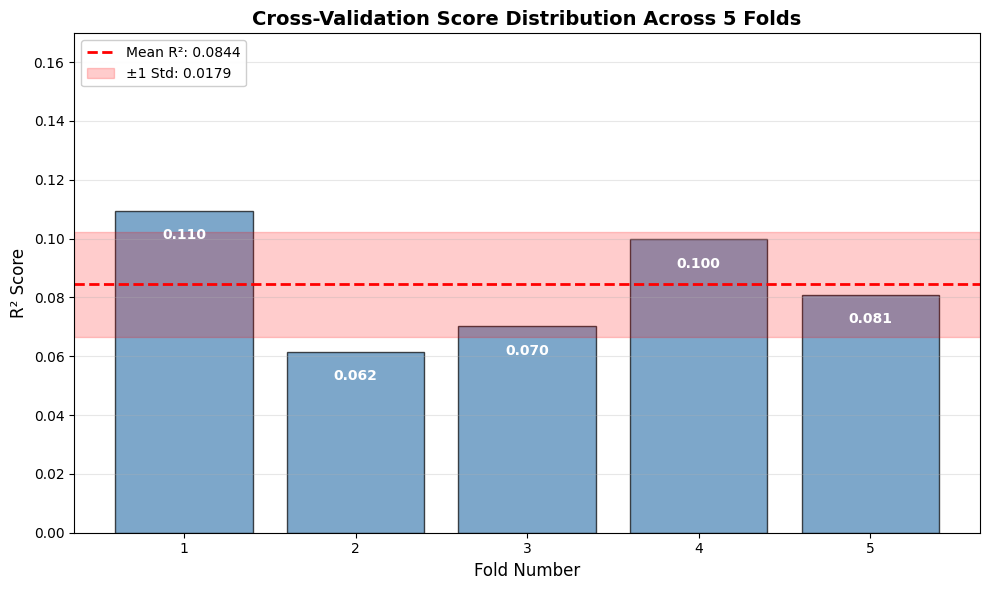


📚 Summary: What You Learned

✅ Complete Solutions Provided:
   1. ✅ Simple train-test split (baseline comparison)
   2. ✅ K-Fold cross-validation (5-fold)
   3. ✅ Manual cross-validation implementation (step-by-step)
   4. ✅ Multiple metrics with cross_validate()
   5. ✅ Model comparison using cross-validation
   6. ✅ K-Fold visualization (how data is split)
   7. ✅ Leave-One-Out CV (LOOCV) for small datasets
   8. ✅ Score distribution visualization

💡 Key Takeaways:
   - Cross-validation gives more reliable evaluation than single split
   - K-Fold (K=5) is the standard choice for most problems
   - LOOCV is best for very small datasets (< 50 samples)
   - Cross-validation enables fair model comparison
   - All solutions are complete and runnable!

Example 1 Complete! ✓


In [22]:
# SOLUTION: Visualize score distribution across folds
# This bar chart shows how R² scores vary across the 5 folds
# Helps us understand if model performance is consistent or variable

plt.figure(figsize=(10, 6))

# SOLUTION: Create bar chart showing R² score for each fold
# Each bar represents the R² score from one fold (height = performance)
bars = plt.bar(range(1, len(all_scores) + 1), all_scores, 
               alpha=0.7, edgecolor='black', color='steelblue')

# SOLUTION: Add mean line
# Red dashed line shows the average R² across all folds
mean_score = np.mean(all_scores)
plt.axhline(mean_score, color='r', linestyle='--', linewidth=2,
           label=f'Mean R²: {mean_score:.4f}')

# SOLUTION: Add standard deviation bands
# Red shaded area shows ±1 standard deviation (68% of scores fall here)
std_score = np.std(all_scores)
plt.axhspan(mean_score - std_score, mean_score + std_score, 
           alpha=0.2, color='red', label=f'±1 Std: {std_score:.4f}')

# SOLUTION: Add value labels on bars
# Placed INSIDE each bar, just under its top edge. Above the bar they would sit at
# the same height as the red mean line for folds 3 and 5 and become unreadable.
for i, (bar, score) in enumerate(zip(bars, all_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.006, f'{score:.3f}',
             ha='center', va='top', fontsize=10, color='white', fontweight='bold')

plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Cross-Validation Score Distribution Across 5 Folds', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left', framealpha=0.95)
plt.grid(True, alpha=0.3, axis='y')
# Bars are drawn from 0, so the axis starts at 0 - anything else would exaggerate
# the differences between folds. Headroom above the tallest bar leaves room for
# the legend without it covering the mean line or the +/-1 std band.
plt.ylim([0, max(all_scores) * 1.55])
plt.xticks(range(1, len(all_scores) + 1))
plt.tight_layout()
print("\n✅ Plot saved as 'cv_score_distribution.png'")
print("\n📊 What This Visualization Shows:")
print("   - Each bar = R² score for one fold (height = performance)")
print("   - Red dashed line = Mean R² across all folds (average performance)")
print("   - Red shaded area = ±1 standard deviation (68% confidence interval)")
print("   - Value labels = Exact R² score for each fold")

print("\n💡 How to Interpret This Plot:")
mean_score = np.mean(all_scores)
std_score = np.std(all_scores)
print(f"   - Mean R²: {mean_score:.4f} (average performance)")
print(f"   - Std: {std_score:.4f} (variation across folds)")
print(f"   - Range: [{min(all_scores):.4f}, {max(all_scores):.4f}] (min to max)")

# Automatic interpretation based on standard deviation
if std_score < 0.05:
    consistency = "✅ Very consistent"
    interpretation = "Model performance is very stable across folds - reliable model!"
elif std_score < 0.1:
    consistency = "✅ Consistent"
    interpretation = "Model performance is fairly stable - good model!"
else:
    consistency = "⚠️  Variable"
    interpretation = "Model performance varies across folds - may need investigation!"

print(f"\n   Consistency: {consistency}")
print(f"   {interpretation}")

print("\n📈 What to Look For:")
print("   - Bars close together → Consistent performance (good!)")
print("   - Bars far apart → Variable performance (investigate!)")
print("   - Mean line in middle → Balanced performance")
print("   - Small shaded area → Low variance (reliable!)")
print("   - Large shaded area → High variance (less reliable)")

print("\n🎯 How to Use This:")
print("   - Compare different models: Lower std = more reliable")
print("   - Check consistency: Small range = stable model")
print("   - Confidence interval: Mean ± Std shows performance range")
print("   - Model selection: Choose models with consistent performance!")

plt.show()

print("\n" + "=" * 60)
print("📚 Summary: What You Learned")
print("=" * 60)
print("\n✅ Complete Solutions Provided:")
print("   1. ✅ Simple train-test split (baseline comparison)")
print("   2. ✅ K-Fold cross-validation (5-fold)")
print("   3. ✅ Manual cross-validation implementation (step-by-step)")
print("   4. ✅ Multiple metrics with cross_validate()")
print("   5. ✅ Model comparison using cross-validation")
print("   6. ✅ K-Fold visualization (how data is split)")
print("   7. ✅ Leave-One-Out CV (LOOCV) for small datasets")
print("   8. ✅ Score distribution visualization")
print("\n💡 Key Takeaways:")
print("   - Cross-validation gives more reliable evaluation than single split")
print("   - K-Fold (K=5) is the standard choice for most problems")
print("   - LOOCV is best for very small datasets (< 50 samples)")
print("   - Cross-validation enables fair model comparison")
print("   - All solutions are complete and runnable!")
print("\n" + "=" * 60)
print("Example 1 Complete! ✓")
print("=" * 60)

### What to see in the bar chart above

Five bars, five fits, five different held-out fifths of the 1,994 communities. The bars are **not**
the same height: fold 2 scores **0.0616** and fold 1 scores **0.1095** — the best fold looks nearly
twice as good as the worst, and *nothing about the model changed between them*. The red dashed line
is the mean (**0.0844**) and the pink band is ±1 standard deviation (**0.0179**), which spans roughly
0.067 to 0.102.

Compare this with the lottery figure earlier in the lesson: those ten *random splits* spanned
0.040–0.126, while these five *folds* span 0.062–0.110 — tighter, because k-fold guarantees the five
test sets partition the data instead of being drawn independently. The honest sentence to write in a
report is the pair, not the best bar: **R² = 0.084 ± 0.018**.

## 📚 References

1. Stone, M. (1974). *Cross-Validatory Choice and Assessment of Statistical Predictions*. Journal of the Royal Statistical Society: Series B, 36(2), 111–147.
2. Kohavi, R. (1995). *A Study of Cross-Validation and Bootstrap for Accuracy Estimation and Model Selection*. IJCAI 1995.
3. Bates, S., Hastie, T., & Tibshirani, R. (2023). *Cross-Validation: What Does It Estimate and How Well Does It Do It?* Journal of the American Statistical Association. <https://arxiv.org/abs/2104.00673>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 5. Springer.
5. Lei, J. (2025). *A Modern Theory of Cross-Validation through the Lens of Stability*. <https://arxiv.org/abs/2505.23592>
6. Erickson, N., Purucker, L., Tschalzev, A., et al. (2025). *TabArena: A Living Benchmark for Machine Learning on Tabular Data*. <https://arxiv.org/abs/2506.16791>
